### 基于K-Means聚类与Prophet时序预测的重庆上市车企财务智能预警研究
#### ——赛力斯外部协同经营模式对标长安自主研发模式
**核心研究问题**：代工协同模式（赛力斯）和自主研发模式（长安），谁的财务风险更高、更不稳定？

---

目录：

- 一、数据获取与预处理
  - 1. 数据获取
  - 2. 数据预处理
- 二、财务指标探索
  - 1. 八家车企核心指标对比
  - 2. 研发投入趋势（赛力斯 vs 长安）
- 三、财务分析
  - 1. K-Means 聚类分析
  - 2. 孤立森林异常检测
  - 3. 指标时序预测
  - 4. 六种预测方法对比
  - 5. 预测方法综合排名
- 四、行业NEV销量与公司财务联动分析
  - 1. NEV 市场行业景气度分析
  - 2. 季度深度分析（长安汽车 & 赛力斯）
  - 3. NEV 增速偏离度分析（赛力斯/长安 vs 行业）
  - 4. 月度季节性模式与同比增速
- 五、综合评价
  - 1. 杜邦分析 ROE 分解
  - 2. Altman Z-score 破产预警 + 沃尔评分排名
  - 3. 销量结构对比
  - 4. 综合风险雷达图 + 四象限散点图
  - 5. 指标时间趋势
- 六、结论与对策建议

---

##### 一、数据获取与预处理
1. 数据获取

（1）获取财务报表数据：2016年Q1-2025年Q4
* `data/collect_financial_data.py` # 获取财务数据
* 获取8家对标车企（赛力斯★/长安汽车★/比亚迪/上汽集团/长城汽车/广汽集团/江淮汽车/北汽蓝谷）的资产负债表、利润表和现金流量表的年度数据，并存到excel中。
  
（2）获取车企销售数据：2023年Q1-2026年Q4
* `data/add_company_sales.py` # 添加公司销售数据
* `data/extract_sales_structure.py` # 获取销售结构数据

（3）2026Q1追加采集财务数据（赛力斯+长安）
* `data/collect_2026q1_for_mape.py`

（4）追加中国汽车行业多维销量数据（2016Q1_2025Q4）
* `data\enrich_nev_data.py`
* `data\nev_industry_analysis.py`

1. 数据预处理

（1）数据读取   

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.weight'] = 'normal'
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['font.weight'] = 'normal'
matplotlib.rcParams['axes.titleweight'] = 'normal'
matplotlib.rcParams['axes.labelweight'] = 'normal'

data_dir = Path('data')
all_data = {
    file.stem.replace('_财务数据', ''): pd.read_excel(file)
    for file in data_dir.glob('*_财务数据.xlsx')
}
for company, df in all_data.items():
    print(f"{company}: {len(df)} 条记录")
list(all_data.values())[0].head()

000625_长安汽车: 69 条记录
002594_比亚迪: 64 条记录
600104_上汽集团: 69 条记录
600418_江淮汽车: 61 条记录
600733_北汽蓝谷: 61 条记录
601127_赛力斯: 63 条记录
601238_广汽集团: 69 条记录
601633_长城汽车: 65 条记录


,Unnamed: 0,2016年报,2016Q1,2016Q2,2016Q3,2017年报,2017Q1,2017Q2,2017Q3,2018年报,...,2023Q3,2024年报,2024Q1,2024Q2,2024Q3,2025年报,2025Q1,2025Q2,2025Q3,2026Q1
0,货币资金,2.478300e+10,1.871700e+10,2.135800e+10,2.510300e+10,2.263200e+10,2.832800e+10,2.788200e+10,2.399200e+10,9.981000e+09,...,7.219200e+10,6.418200e+10,7.006800e+10,7.093900e+10,7.000500e+10,5.402200e+10,6.012900e+10,5.283000e+10,5.524100e+10,3.983100e+10
1,交易性金融资产,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.570000e+08,1.550000e+08,1.440000e+08,1.530000e+08,1.670000e+08,NaN,1.500000e+08,1.620000e+08,1.024000e+05,8.000000e+07
2,应收账款,1.499000e+09,1.270000e+09,1.480000e+09,1.518000e+09,1.807000e+09,2.427000e+09,1.900000e+09,1.996000e+09,1.409000e+09,...,2.669000e+09,3.398000e+09,3.277000e+09,2.989000e+09,4.226000e+09,4.197000e+09,5.021000e+09,6.628000e+09,7.216000e+09,1.173500e+10
3,应收票据及应收账款,3.050100e+10,2.414100e+10,2.131300e+10,2.162200e+10,3.096300e+10,2.588000e+10,2.363500e+10,2.336100e+10,2.197100e+10,...,3.804700e+10,4.897900e+10,3.698200e+10,3.698500e+10,3.344300e+10,3.719500e+10,4.285000e+10,3.218500e+10,2.773400e+10,4.075400e+10
4,预付款项,1.061000e+09,6.700000e+08,9.910000e+08,8.800000e+08,1.102000e+09,1.323000e+09,1.274000e+09,1.832000e+09,8.660000e+08,...,9.880000e+08,5.070000e+08,4.820000e+08,5.830000e+08,4.560000e+08,4.920000e+08,4.360000e+08,4.000000e+08,7.940000e+08,7.190000e+08


(2) 报表合并

In [2]:
def integrate_financial_data(company_code):
    file_path = f'data/{company_code}_财务数据.xlsx'
    df_balance = pd.read_excel(file_path, sheet_name='资产负债表', index_col=0)
    df_income  = pd.read_excel(file_path, sheet_name='利润表', index_col=0)
    df_cash    = pd.read_excel(file_path, sheet_name='现金流量表', index_col=0)
    df_balance = df_balance.T.add_suffix('_资产')
    df_income  = df_income.T.add_suffix('_利润')
    df_cash    = df_cash.T.add_suffix('_现金流')
    
    data = pd.concat([df_income, df_balance, df_cash], axis=1).fillna(0)
    print(f'完成: {len(data)} 期 × {len(data.columns)} 个指标')
    return data  

companies = [f.stem.replace('_财务数据','') for f in Path('data').glob('*_财务数据.xlsx')]
print('可用公司:', companies)
data = integrate_financial_data('601127_赛力斯')
data.info()
data.head()

可用公司: ['000625_长安汽车', '002594_比亚迪', '600104_上汽集团', '600418_江淮汽车', '600733_北汽蓝谷', '601127_赛力斯', '601238_广汽集团', '601633_长城汽车']
完成: 42 期 × 157 个指标
<class 'pandas.DataFrame'>
Index: 42 entries, 2016年报 to 2026Q1.1
Columns: 157 entries, 一、营业总收入_利润 to 间接法-现金及现金等价物净增加额_现金流
dtypes: float64(157)
memory usage: 51.8+ KB


,一、营业总收入_利润,营业收入_利润,税金及附加_利润,销售费用_利润,管理费用_利润,研发费用_利润,财务费用_利润,其中：利息费用_利润,其中：利息收入_利润,投资收益_利润,...,投资损失_现金流,递延所得税资产减少_现金流,递延所得税负债增加_现金流,存货的减少_现金流,经营性应收项目的减少_现金流,经营性应付项目的增加_现金流,间接法-经营活动产生的现金流量净额_现金流,现金的期末余额_现金流,减：现金的期初余额_现金流,间接法-现金及现金等价物净增加额_现金流
2016年报,1.619243e+10,1.619243e+10,5.070655e+08,1.040867e+09,8.576498e+08,0.000000e+00,31223587.42,0.000000e+00,0.000000e+00,17085648.52,...,-17085600.0,-2747300.0,-2803400.0,-398000000.0,-3.166000e+09,3.396000e+09,1.146000e+09,2.354000e+09,7.830000e+08,1.571000e+09
2016Q1,3.192494e+09,3.192494e+09,8.975824e+07,2.354520e+08,1.904555e+08,0.000000e+00,19150137.50,0.000000e+00,0.000000e+00,3113381.63,...,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2016Q2,6.335556e+09,6.335556e+09,1.679867e+08,4.499726e+08,3.629218e+08,0.000000e+00,39083090.27,0.000000e+00,0.000000e+00,4811555.19,...,-4811600.0,2414900.0,-1409500.0,-94636200.0,-9.450730e+07,2.320000e+08,6.140000e+08,1.813000e+09,7.830000e+08,1.030000e+09
2016Q3,1.020144e+10,1.020144e+10,2.830919e+08,7.015685e+08,5.480660e+08,0.000000e+00,49897945.70,0.000000e+00,0.000000e+00,13988970.02,...,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2017年报,2.193376e+10,2.193376e+10,6.996699e+08,1.282389e+09,9.138462e+08,4.678123e+08,30211619.41,1.378618e+08,1.179849e+08,14875439.06,...,-14875400.0,-7041700.0,-2344900.0,-242000000.0,-9.310000e+08,1.340000e+08,9.970000e+08,4.366000e+09,2.354000e+09,2.012000e+09


(3) 插到新table

In [3]:
# 追加合并报表 sheet
for fp in Path('data').glob('*_财务数据.xlsx'):
    code = fp.stem.replace('_财务数据', '')
    data = integrate_financial_data(code)
    with pd.ExcelWriter(fp, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        data.to_excel(writer, sheet_name='合并报表', index=True)
    print(f' {code}: 已追加合并报表 ({len(data)}期×{len(data.columns)}指标)')

完成: 41 期 × 163 个指标
 000625_长安汽车: 已追加合并报表 (41期×163指标)
完成: 40 期 × 159 个指标
 002594_比亚迪: 已追加合并报表 (40期×159指标)
完成: 40 期 × 167 个指标
 600104_上汽集团: 已追加合并报表 (40期×167指标)
完成: 40 期 × 155 个指标
 600418_江淮汽车: 已追加合并报表 (40期×155指标)
完成: 40 期 × 149 个指标
 600733_北汽蓝谷: 已追加合并报表 (40期×149指标)
完成: 42 期 × 157 个指标
 601127_赛力斯: 已追加合并报表 (42期×157指标)
完成: 40 期 × 169 个指标
 601238_广汽集团: 已追加合并报表 (40期×169指标)
完成: 40 期 × 160 个指标
 601633_长城汽车: 已追加合并报表 (40期×160指标)


（4） 静态财务指标
* 盈利能力、营运能力、偿债能力、成长能力

In [4]:
def financial_ratio(name, data):
    # 计算18个财务指标（原15个 + 有息负债率 + 经营现金流/营收 + 权益乘数）
    col = {
        '营收': '营业收入_利润', '营成': '营业成本_利润', '营利': '营业利润_利润',
        '净利': '净利润_利润', '归母净利': '归属于母公司所有者的净利润_利润',
        '利息': '其中：利息费用_利润', '存货': '存货_资产', '资产': '资产合计_资产',
        '负债': '负债合计_资产', '货币资金': '货币资金_资产', '应收': '应收账款_资产',
        '流资': '流动资产合计_资产', '流负': '流动负债合计_资产',
        '预付': '预付款项_资产', '权益': '归属于母公司所有者权益合计_资产',
    }

    # 有息负债列检测
    ib_keys = ['短期借款_资产','长期借款_资产','应付债券_资产','一年内到期的非流动负债_资产']
    ib_cols = {k: data[k] for k in ib_keys if k in data.columns}
    has_ib = len(ib_cols) > 0

    # 经营现金流列检测
    ocf_col = None
    for c in data.columns:
        if '经营' in c and '现金流' in c and '净额' in c:
            ocf_col = c; break

    # 新列一次性构建
    new_cols = {}
    new_cols['息税前利润'] = data[col['营利']] + data[col['利息']]
    new_cols['毛利率'] = 1 - data[col['营成']] / data[col['营收']]
    new_cols['营业利润率'] = data[col['营利']] / data[col['营收']]
    new_cols['净利润率'] = data[col['净利']] / data[col['营收']]
    new_cols['净资产收益率'] = 2 * data[col['归母净利']] / (
        data[col['权益']] + data[col['权益']].shift(1))
    new_cols['存货周转率'] = 2 * data[col['营成']] / (
        data[col['存货']] + data[col['存货']].shift(1))
    new_cols['总资产周转率'] = 2 * data[col['营收']] / (
        data[col['资产']] + data[col['资产']].shift(1))
    new_cols['应收账款周转率'] = 2 * data[col['营收']] / (
        data[col['应收']] + data[col['应收']].shift(1))
    new_cols['流动比率'] = data[col['流资']] / data[col['流负']]
    new_cols['速动比率'] = (data[col['流资']] - data[col['存货']] - data[col['预付']]) / data[col['流负']]
    new_cols['利息保障倍数'] = new_cols['息税前利润'] / data[col['利息']]
    new_cols['资产负债率'] = data[col['负债']] / data[col['资产']]
    new_cols['货币资金占比'] = data[col['货币资金']] / data[col['资产']]
    new_cols['营业收入增长率'] = data[col['营收']] / data[col['营收']].shift(1) - 1
    new_cols['营业利润增长率'] = data[col['营利']] / data[col['营利']].shift(1) - 1
    new_cols['净利润增长率'] = data[col['净利']] / data[col['净利']].shift(1) - 1

    if has_ib:
        total_ib = sum(ib_cols.values())
        new_cols['有息负债率'] = total_ib / data[col['资产']]
    else:
        new_cols['有息负债率'] = np.nan

    if ocf_col:
        new_cols['经营现金流/营收'] = data[ocf_col] / data[col['营收']]
    else:
        new_cols['经营现金流/营收'] = np.nan

    new_cols['权益乘数'] = data[col['资产']] / data[col['权益']]

    df_new = pd.concat(new_cols, axis=1)

    cols = ['毛利率','营业利润率','净利润率','净资产收益率',
            '存货周转率','总资产周转率','应收账款周转率',
            '流动比率','速动比率','利息保障倍数','资产负债率','货币资金占比',
            '营业收入增长率','营业利润增长率','净利润增长率',
            '有息负债率','经营现金流/营收','权益乘数']
    df = df_new[cols].iloc[1:].copy()
    df.index = data.index[1:]
    df[np.isinf(df)] = 0

    with pd.ExcelWriter(f'data/{name}_财务数据.xlsx',
                        engine='openpyxl', mode='a',
                        if_sheet_exists='replace') as writer:
        df.to_excel(writer, sheet_name='财务指标表', index=True)

    print(f' {name}: 财务指标表已保存 ({len(df)}期x{len(df.columns)}指标)')
    return df
data = integrate_financial_data('601127_赛力斯')
df_ratio = financial_ratio(name='601127_赛力斯', data=data)
df_ratio.head()

完成: 42 期 × 157 个指标
 601127_赛力斯: 财务指标表已保存 (41期x18指标)


,毛利率,营业利润率,净利润率,净资产收益率,存货周转率,总资产周转率,应收账款周转率,流动比率,速动比率,利息保障倍数,资产负债率,货币资金占比,营业收入增长率,营业利润增长率,净利润增长率,有息负债率,经营现金流/营收,权益乘数
2016Q1,0.043866,0.044842,0.042124,0.035970,5.595694,0.188598,16.246791,NaN,NaN,0.000000,0.762251,0.000000,-0.802840,-0.799713,-0.788253,0.000000,0.058575,5.163536
2016Q2,0.035776,0.036536,0.034175,0.062562,15.028030,0.433749,30.241316,0.906216,0.810236,0.000000,0.726142,0.196196,0.984516,0.616925,0.610027,0.140187,0.096913,4.294517
2016Q3,0.031950,0.033321,0.031242,0.081030,11.777589,0.629952,24.700825,0.902486,0.792878,0.000000,0.752065,0.191288,0.610189,0.468511,0.472005,0.128184,0.084400,4.732728
2017年报,0.057857,0.063177,0.050213,0.173452,18.769072,1.072346,32.160944,0.996867,0.882267,11.051469,0.754407,0.247154,1.150065,3.076576,2.455630,0.209117,0.045455,5.019898
2017Q1,0.059936,0.060224,0.048794,0.045958,3.692621,0.260812,8.833686,0.894994,0.770151,0.000000,0.772137,0.225941,-0.732175,-0.744695,-0.739740,0.131407,0.088690,5.263509


In [5]:
all_ratios = {}
for fp in Path('data').glob('*_财务数据.xlsx'):
    code = fp.stem.replace('_财务数据', '')
    print(f'处理: {code} ... ', end='')
    
    xl = pd.ExcelFile(fp)
    if '合并报表' in xl.sheet_names:
        data = pd.read_excel(xl, '合并报表', index_col=0)
    else:
        data = integrate_financial_data(code)

    df_ratio = financial_ratio(name=code, data=data)
    all_ratios[code] = df_ratio
    print(f'OK ({len(df_ratio)}期)')
print(f'\n 完成: {len(all_ratios)} 家公司')

处理: 000625_长安汽车 ...  000625_长安汽车: 财务指标表已保存 (40期x18指标)
OK (40期)
处理: 002594_比亚迪 ...  002594_比亚迪: 财务指标表已保存 (39期x18指标)
OK (39期)
处理: 600104_上汽集团 ...  600104_上汽集团: 财务指标表已保存 (39期x18指标)
OK (39期)
处理: 600418_江淮汽车 ...  600418_江淮汽车: 财务指标表已保存 (39期x18指标)
OK (39期)
处理: 600733_北汽蓝谷 ...  600733_北汽蓝谷: 财务指标表已保存 (39期x18指标)
OK (39期)
处理: 601127_赛力斯 ...  601127_赛力斯: 财务指标表已保存 (41期x18指标)
OK (41期)
处理: 601238_广汽集团 ...  601238_广汽集团: 财务指标表已保存 (39期x18指标)
OK (39期)
处理: 601633_长城汽车 ...  601633_长城汽车: 财务指标表已保存 (39期x18指标)
OK (39期)

 完成: 8 家公司


##### 二、财务指标探索

1.八家车企核心指标对比（热力图）

findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


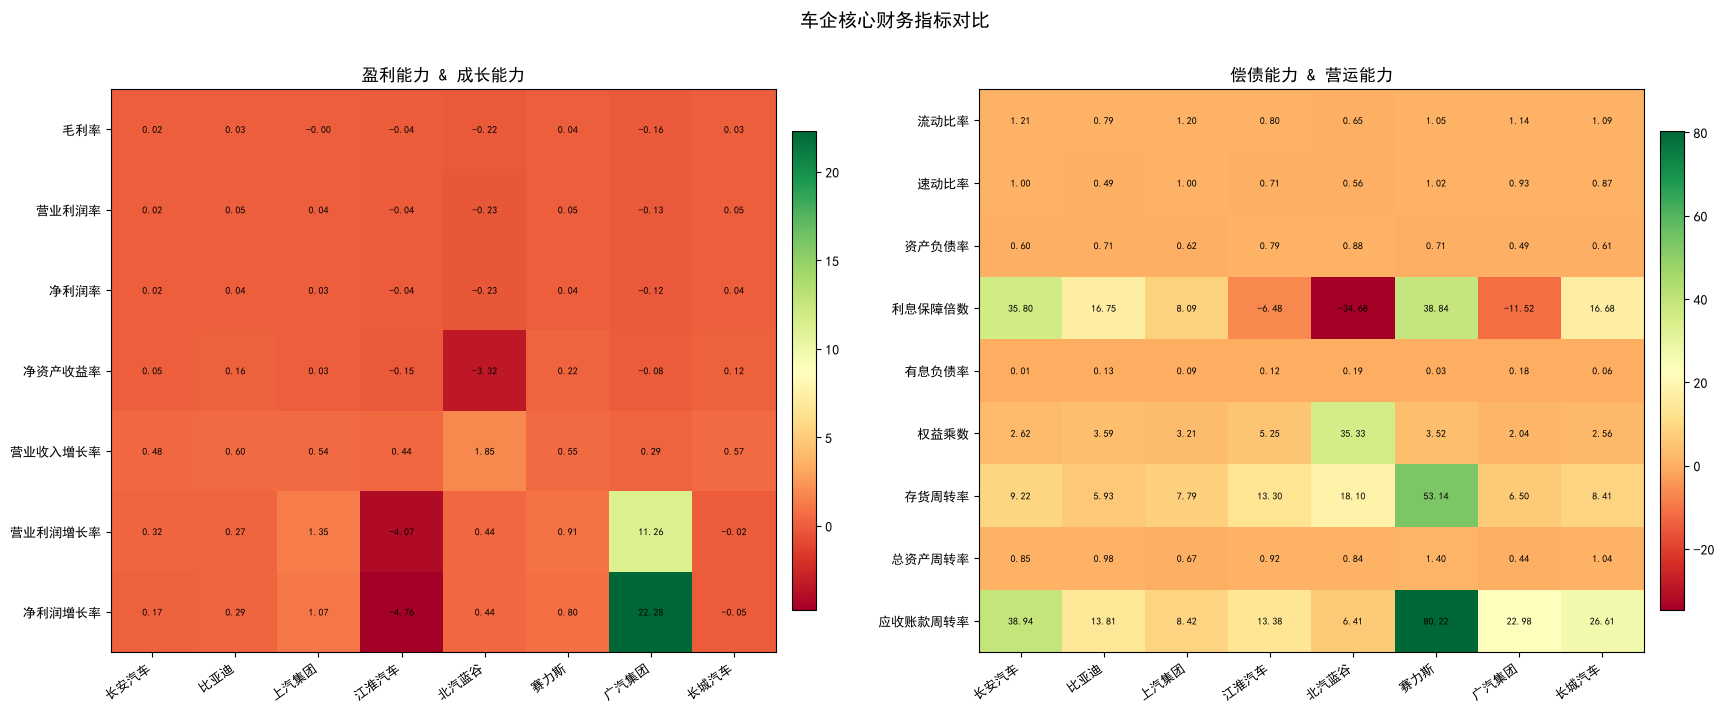

In [6]:
METRICS_LEFT  = ['毛利率','营业利润率','净利润率','净资产收益率',
                 '营业收入增长率','营业利润增长率','净利润增长率']
METRICS_RIGHT = ['流动比率','速动比率','资产负债率','利息保障倍数',
                 '有息负债率','权益乘数','存货周转率','总资产周转率','应收账款周转率']
ALL_METRICS = METRICS_LEFT + METRICS_RIGHT

summary = []
for code, df_r in all_ratios.items():
    name = code.split('_')[1]
    annual = [i for i in df_r.index if '年报' in str(i)]
    if not annual: continue
    latest = annual[-1]
    row = {'公司': name}
    for m in ALL_METRICS:
        row[m] = df_r.loc[latest, m] if latest in df_r.index and m in df_r.columns else None
    summary.append(row)

df_summary = pd.DataFrame(summary).set_index('公司')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

for ax, metrics, title in [
    (ax1, METRICS_LEFT,  '盈利能力 & 成长能力'),
    (ax2, METRICS_RIGHT, '偿债能力 & 营运能力'),
]:
    df_sub = df_summary[metrics]
    im = ax.imshow(df_sub.T, cmap='RdYlGn', aspect='auto')
    ax.set_xticks(range(len(df_sub)))
    ax.set_xticklabels(df_sub.index, rotation=35, ha='right', fontsize=9)
    ax.set_yticks(range(len(metrics)))
    ax.set_yticklabels(metrics, fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    for i in range(len(metrics)):
        for j in range(len(df_sub)):
            val = df_sub.iloc[j, i]
            if pd.notna(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7.5)
    plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)

fig.suptitle('车企核心财务指标对比', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('reports/pictures/financial_metrics_comparison.png', dpi=100, bbox_inches='tight')
plt.tight_layout(); plt.show()

2.研发投入趋势 (赛力斯 vs 长安)

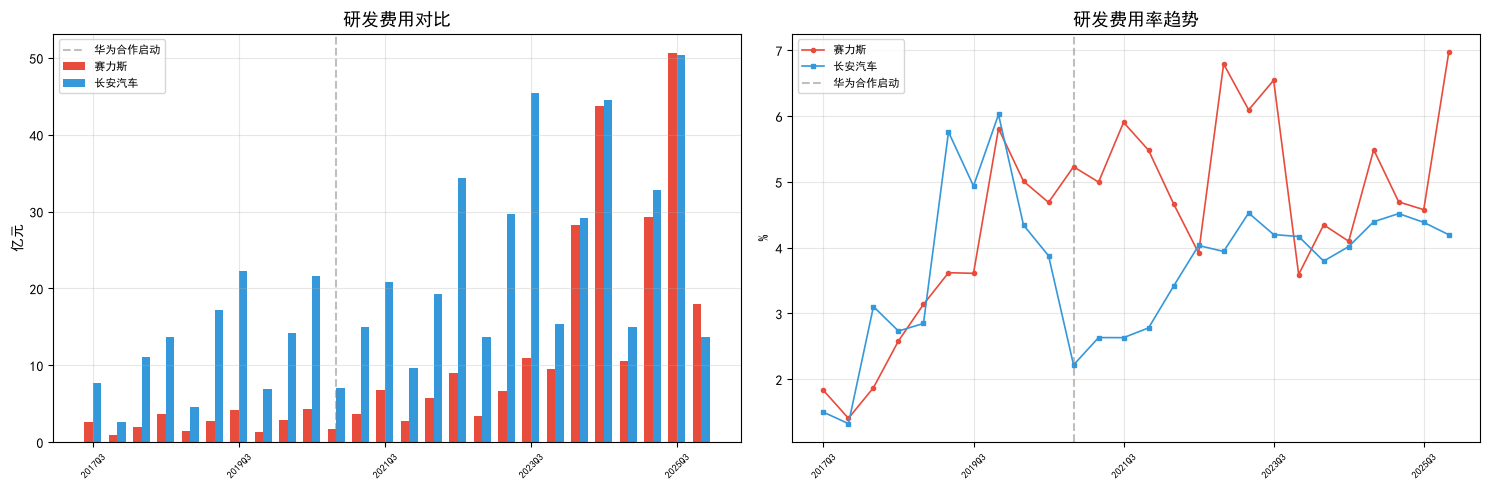


最新季度 — 赛力斯研发17.9亿(率7.0%)
 长安研发13.7亿(率4.2%)


In [7]:
def _rd(code):
    df = pd.read_excel(f'data/{code}_财务数据.xlsx', sheet_name='利润表', index_col=0)
    qs = [c for c in df.columns if 'Q' in str(c)]
    rs = []
    for q in qs:
        rd = pd.to_numeric(df.loc['研发费用', q], errors='coerce')
        rv = pd.to_numeric(df.loc['营业收入', q], errors='coerce')
        if pd.notna(rd) and pd.notna(rv) and rv > 0:
            rs.append({'季度': str(q), '研发费用(亿)': rd/1e8, '研发率(%)': rd/rv*100})
    return pd.DataFrame(rs)

sl = _rd('601127_赛力斯')
ca = _rd('000625_长安汽车')
if sl is not None and ca is not None:
    df_rd = sl.merge(ca, on='季度', suffixes=('_赛力斯', '_长安'))
    labels = df_rd['季度'].tolist()
    x = range(len(df_rd))
    hw = next((i for i,l in enumerate(labels) if '2021' in l), None)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    for ax, col, unit in [(ax1, '研发费用(亿)', '亿元'), (ax2, '研发率(%)', '%')]:
        if ax == ax1:   # 仅左侧子图改为柱状图，右侧完全保持原样
            bar_width = 0.35
            ax.bar([p - bar_width/2 for p in x], df_rd[f'{col}_赛力斯'],
                   bar_width, color='#E74C3C', label='赛力斯')
            ax.bar([p + bar_width/2 for p in x], df_rd[f'{col}_长安'],
                   bar_width, color='#3498DB', label='长安汽车')
        else:
            ax.plot(x, df_rd[f'{col}_赛力斯'], 'o-', color='#E74C3C', lw=1.2, ms=3, label='赛力斯')
            ax.plot(x, df_rd[f'{col}_长安'], 's-', color='#3498DB', lw=1.2, ms=3, label='长安汽车')

        if hw is not None:
            ax.axvline(x=hw, color='gray', ls='--', alpha=.5, label='华为合作启动')
        ax.set_xticks([i for i in x if i%6==0])
        ax.set_xticklabels([labels[i] for i in x if i%6==0], rotation=45, fontsize=7)
        ax.set_ylabel(unit)
        ax.legend(fontsize=8)
        ax.grid(alpha=.3)

    ax1.set_title('研发费用对比', fontsize=13)
    ax2.set_title('研发费用率趋势', fontsize=13)
    plt.tight_layout()
    plt.savefig('reports/pictures/rd_expense_comparison.png', dpi=100, bbox_inches='tight')
    plt.show()

    l = df_rd.iloc[-1]
    print(f"\n最新季度 — 赛力斯研发{l['研发费用(亿)_赛力斯']:.1f}亿(率{l['研发率(%)_赛力斯']:.1f}%)")
    print(f" 长安研发{l['研发费用(亿)_长安']:.1f}亿(率{l['研发率(%)_长安']:.1f}%)")

##### 三、财务分析

1. K-Means 聚类分析（8家车企风险分群，K=3）

  000625_长安汽车: 40 季度点
  002594_比亚迪: 39 季度点
  600104_上汽集团: 38 季度点
  600418_江淮汽车: 39 季度点
  600733_北汽蓝谷: 39 季度点
  601127_赛力斯: 41 季度点
  601238_广汽集团: 39 季度点
  601633_长城汽车: 39 季度点

季度数据集: 314 条 (8家x~39季度)
五维指标: ['毛利率', '经营现金流/营收', '有息负债率', '存货周转率', '权益乘数']


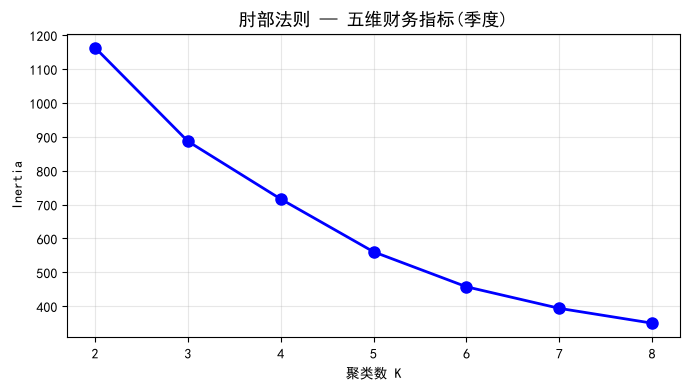

findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


  K-Means 聚类 (K=3, 314季度点)
  五维矩阵: 偿债+盈利+营运+现金流+杠杆
  群0 (8企/287季): 长安汽车, 比亚迪, 上汽集团, 江淮汽车, 北汽蓝谷, 赛力斯, 广汽集团, 长城汽车
    毛利率: -0.011
    经营现金流/营收: -0.020
    有息负债率: 0.124
    存货周转率: 7.954
    权益乘数: 3.104
  群1 (1企/3季): 北汽蓝谷
    毛利率: -1.075
    经营现金流/营收: -8.312
    有息负债率: 0.000
    存货周转率: 0.047
    权益乘数: 1.983
  群2 (1企/24季): 北汽蓝谷
    毛利率: -0.528
    经营现金流/营收: -0.208
    有息负债率: 0.382
    存货周转率: 4.533
    权益乘数: 7.285

--- 各企业综合风险评分（五维矩阵） ---
  ⚠️ 赛力斯: 0.692
  ⚠️ 长安汽车: 0.674
  ⚠️ 北汽蓝谷: 0.663
  ⚠️ 广汽集团: 0.634
  ⚠️ 比亚迪: 0.571
  ⚠️ 上汽集团: 0.547
  ⚠️ 江淮汽车: 0.539
  ✅ 长城汽车: 0.483

  轮廓系数: 0.609  CH指数: 119.8


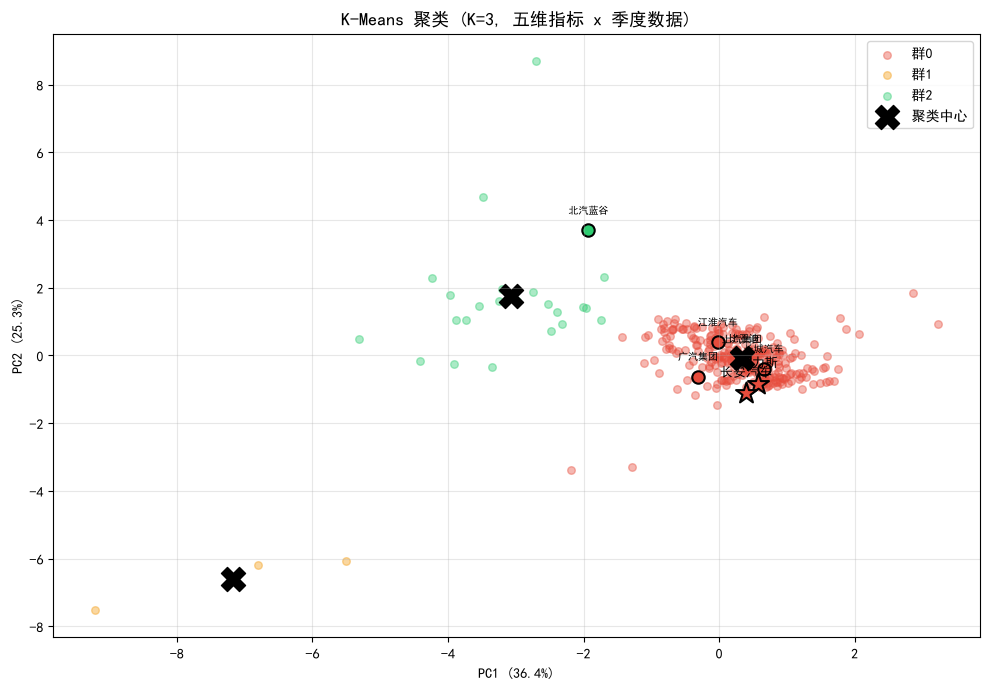

In [8]:
import os; os.environ['LOKY_MAX_CPU_COUNT'] = '4'
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
FEATURES = ['毛利率','经营现金流/营收','有息负债率','存货周转率','权益乘数'] # 偿债+盈利+营运+现金流+杠杆

# 季度数据构建（320点）
def _qdf(code):
    fp = f'data/{code}_财务数据.xlsx'
    xl = pd.ExcelFile(fp)
    if '合并报表' not in xl.sheet_names: return None
    m = pd.read_excel(xl,'合并报表',index_col=0)
    name = code.split('_')[1]
    rs = []
    for p in m.index:
        # 毛利率
        rev = m.loc[p,'营业收入_利润'] if '营业收入_利润' in m.columns else np.nan
        cost = m.loc[p,'营业成本_利润'] if '营业成本_利润' in m.columns else np.nan
        gm = 1 - cost/rev if (pd.notna(rev) and pd.notna(cost) and rev!=0) else np.nan
        # 经营现金流/营收
        ocf_cols = [c for c in m.columns if '经营' in c and '现金流' in c and '净额' in c]
        ocf = m.loc[p,ocf_cols[0]] if ocf_cols else np.nan
        ocf_r = ocf/rev if (pd.notna(ocf) and pd.notna(rev) and rev!=0) else np.nan
        # 有息负债率: (短期借款+长期借款+应付债券+一年内到期非流动负债)/总资产
        ib_keys = ['短期借款_资产','长期借款_资产','应付债券_资产','一年内到期的非流动负债_资产']
        ib = 0; ta = np.nan
        if '资产合计_资产' in m.columns:
            ta = m.loc[p,'资产合计_资产']
        for k in ib_keys:
            if k in m.columns:
                v = pd.to_numeric(m.loc[p,k], errors='coerce')
                if pd.notna(v): ib += v
        idr = ib/ta if (pd.notna(ta) and ta!=0) else np.nan
        # 存货周转率 & 权益乘数
        it = np.nan; em = np.nan
        # 权益乘数 = 总资产/归母权益
        if '资产合计_资产' in m.columns and '归属于母公司所有者权益合计_资产' in m.columns:
            eq = m.loc[p,'归属于母公司所有者权益合计_资产']
            ta2 = m.loc[p,'资产合计_资产']
            em = ta2/eq if (pd.notna(eq) and pd.notna(ta2) and eq!=0) else np.nan
        # 存货周转率: 优先从all_ratios获取
        if code in all_ratios and p in all_ratios[code].index:
            ar = all_ratios[code].loc[p]
            it = ar.get('存货周转率',np.nan)
        elif '存货_资产' in m.columns and '营业成本_利润' in m.columns:
            inv_cur = m.loc[p,'存货_资产']
            prev_idx = m.index.get_loc(p)-1
            if prev_idx >= 0:
                inv_prev = m.iloc[prev_idx]['存货_资产']
                it = cost/((inv_cur+inv_prev)/2) if (pd.notna(cost) and pd.notna(inv_cur) and pd.notna(inv_prev) and (inv_cur+inv_prev)!=0) else np.nan
        rs.append({'code':code,'name':name,'period':p,
                   '毛利率':gm,'经营现金流/营收':ocf_r,'有息负债率':idr,
                   '存货周转率':it,'权益乘数':em})
    return pd.DataFrame(rs).dropna()

dfs = []
for fp in Path('data').glob('*_财务数据.xlsx'):
    code = fp.stem.replace('_财务数据','')
    df = _qdf(code)
    if df is not None and len(df) > 0:
        dfs.append(df)
        print(f'  {code}: {len(df)} 季度点')
df_kmeans = pd.concat(dfs, ignore_index=True)
print(f'\n季度数据集: {len(df_kmeans)} 条 (8家x~{len(df_kmeans)//8}季度)')
print(f'五维指标: {FEATURES}')

X = df_kmeans[FEATURES].values
X_scaled = StandardScaler().fit_transform(X)

# 肘部法则
inertias = []; K_range = range(2,min(9,len(df_kmeans)//4))
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10); km.fit(X_scaled)
    inertias.append(km.inertia_)
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(K_range, inertias, 'bo-', lw=2, ms=8)
ax.set_xlabel('聚类数 K'); ax.set_ylabel('Inertia')
ax.set_title('肘部法则 — 五维财务指标(季度)', fontsize=13)
ax.grid(alpha=0.3); plt.tight_layout(); plt.savefig('reports/pictures/elbow_method.png', dpi=150, bbox_inches='tight'); plt.show()

OPTIMAL_K = 3
km = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_kmeans['cluster'] = km.fit_predict(X_scaled)

print('='*60)
print(f'  K-Means 聚类 (K={OPTIMAL_K}, {len(df_kmeans)}季度点)')
print(f'  五维矩阵: 偿债+盈利+营运+现金流+杠杆')
print('='*60)
for c in range(OPTIMAL_K):
    mask = df_kmeans['cluster']==c
    members = df_kmeans[mask]['name'].unique()
    avg = df_kmeans[mask][FEATURES].mean()
    print(f'  群{c} ({len(members)}企/{mask.sum()}季): {", ".join(members)}')
    for f in FEATURES:
        print(f'    {f}: {avg[f]:.3f}')

# 综合风险评分（基于预警方向，侧重预警而非盈利）
df_kmeans['risk_score'] = (
    (1-df_kmeans['毛利率'].clip(upper=0.5))*0.15+
    (1-df_kmeans['经营现金流/营收'].clip(upper=2))*0.25+
    df_kmeans['有息负债率'].clip(upper=1)*0.25+
    (1-df_kmeans['存货周转率'].clip(upper=15)/15)*0.15+
    df_kmeans['权益乘数'].clip(upper=10)/10*0.20
)
# 按公司汇总（取最新季度风险分）
latest_risk = df_kmeans.sort_values('period').groupby('name').last()['risk_score'].sort_values(ascending=False)
print('\n--- 各企业综合风险评分（五维矩阵） ---')
for name, score in latest_risk.items():
    icon = '🔴' if score>0.7 else ('⚠️' if score>0.5 else '✅')
    print(f'  {icon} {name}: {score:.3f}')

# 聚类评估
sil = silhouette_score(X_scaled, df_kmeans['cluster'])
ch = calinski_harabasz_score(X_scaled, df_kmeans['cluster'])
print(f'\n  轮廓系数: {sil:.3f}  CH指数: {ch:.1f}')

# PCA可视化
pca = PCA(n_components=2); X_pca = pca.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E74C3C','#F39C12','#2ECC71'][:OPTIMAL_K]
for c in range(OPTIMAL_K):
    mask = df_kmeans['cluster']==c
    ax.scatter(X_pca[mask,0], X_pca[mask,1], c=colors[c], s=30, alpha=0.4, label=f'群{c}')
for i, row in df_kmeans.groupby('name').last().iterrows():
    idx = df_kmeans[df_kmeans['name']==i].index[-1]
    is_core = i in ['赛力斯','长安汽车']
    ax.scatter(X_pca[idx,0], X_pca[idx,1], c=colors[row['cluster']], s=250 if is_core else 80,
               marker='*' if is_core else 'o', edgecolors='black', linewidths=1.5)
    ax.annotate(i, (X_pca[idx,0], X_pca[idx,1]), fontsize=9 if is_core else 7, ha='center',
                xytext=(0,12), textcoords='offset points', fontweight='bold' if is_core else 'normal')
centers_pca = pca.transform(km.cluster_centers_)
ax.scatter(centers_pca[:,0], centers_pca[:,1], c='black', marker='X', s=300, label='聚类中心')
ax.set_title(f'K-Means 聚类 (K={OPTIMAL_K}, 五维指标 x 季度数据)', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); 
plt.savefig('reports/pictures/kmeans_pca.png', dpi=100, bbox_inches='tight')
plt.show()

2. 孤立森林异常检测

孤立森林 异常检测 (五维矩阵, 季度数据)
总计: 314 个季度数据点

  🔴 北汽蓝谷: 异常率=74%, 均分=-0.057, 点数=39
  ✅ 赛力斯: 异常率=7%, 均分=0.080, 点数=41
  ✅ 比亚迪: 异常率=0%, 均分=0.101, 点数=39
  ✅ 广汽集团: 异常率=0%, 均分=0.113, 点数=39
  ✅ 长安汽车: 异常率=0%, 均分=0.114, 点数=40
  ✅ 江淮汽车: 异常率=0%, 均分=0.114, 点数=39
  ✅ 长城汽车: 异常率=0%, 均分=0.118, 点数=39
  ✅ 上汽集团: 异常率=0%, 均分=0.140, 点数=38


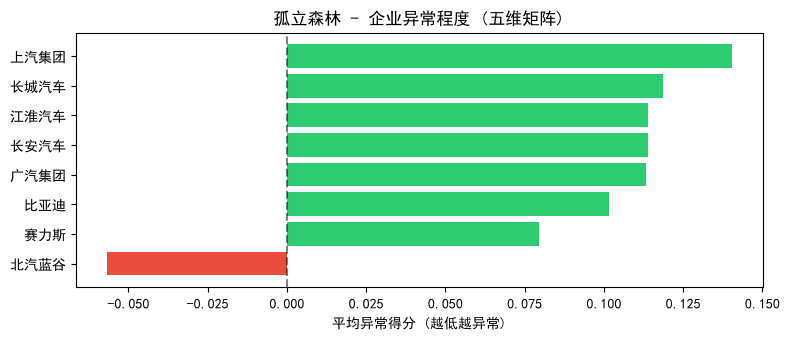

In [9]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.10, random_state=42)
anomaly_labels = iso.fit_predict(X_scaled)
anomaly_scores = iso.decision_function(X_scaled)
df_kmeans['anomaly'] = anomaly_labels
df_kmeans['anomaly_score'] = anomaly_scores

anomaly_summary = df_kmeans.groupby('name').agg(
    anomaly_rate=('anomaly', lambda x: (x == -1).mean()),
    avg_score=('anomaly_score', 'mean'),
    point_count=('anomaly', 'count')
).sort_values('avg_score')

print(f'孤立森林 异常检测 (五维矩阵, 季度数据)')
print(f'总计: {len(df_kmeans)} 个季度数据点\n')
for name, row in anomaly_summary.iterrows():
    flag = '🔴' if row['anomaly_rate'] > 0.3 else ('⚠️' if row['anomaly_rate'] > 0.1 else '✅')
    print(f'  {flag} {name}: 异常率={row["anomaly_rate"]*100:.0f}%, 均分={row["avg_score"]:.3f}, 点数={int(row["point_count"])}')

fig, ax = plt.subplots(figsize=(8, 3.5))
colors_bar = ['#E74C3C' if s < -0.05 else '#2ECC71' for s in anomaly_summary['avg_score']]
ax.barh(range(len(anomaly_summary)), anomaly_summary['avg_score'], color=colors_bar)
ax.set_yticks(range(len(anomaly_summary)))
ax.set_yticklabels(anomaly_summary.index)
ax.axvline(x=0, color='black', ls='--', alpha=0.5)
ax.set_xlabel('平均异常得分 (越低越异常)')
ax.set_title('孤立森林 - 企业异常程度 (五维矩阵)', fontsize=12)
plt.tight_layout()
plt.savefig('reports/pictures/isolation_forest_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

3. 指标时序预测（赛力斯 vs 长安）

（1）Prophet 时序预测

f:\FIDAC\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
16:37:08 - cmdstanpy - INFO - Chain [1] start processing



  赛力斯（未来4个季度预测）


16:37:08 - cmdstanpy - INFO - Chain [1] done processing
findfont: Failed to find font weight bold, now using 400.


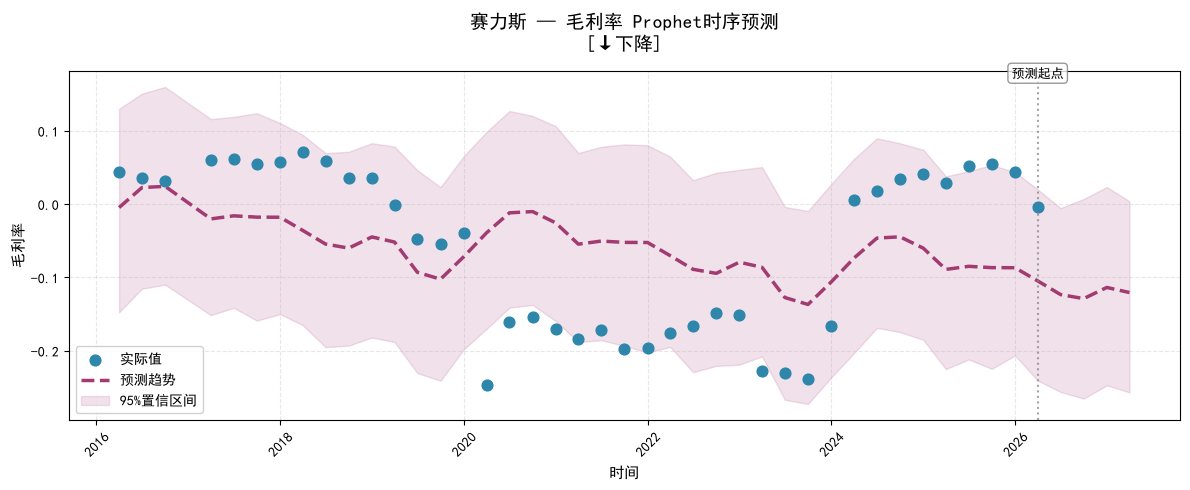

16:37:09 - cmdstanpy - INFO - Chain [1] start processing


  赛力斯 毛利率: ↓下降
    当前: -0.0046 → 预测: -0.1206 (-2521.6%)


16:37:09 - cmdstanpy - INFO - Chain [1] done processing


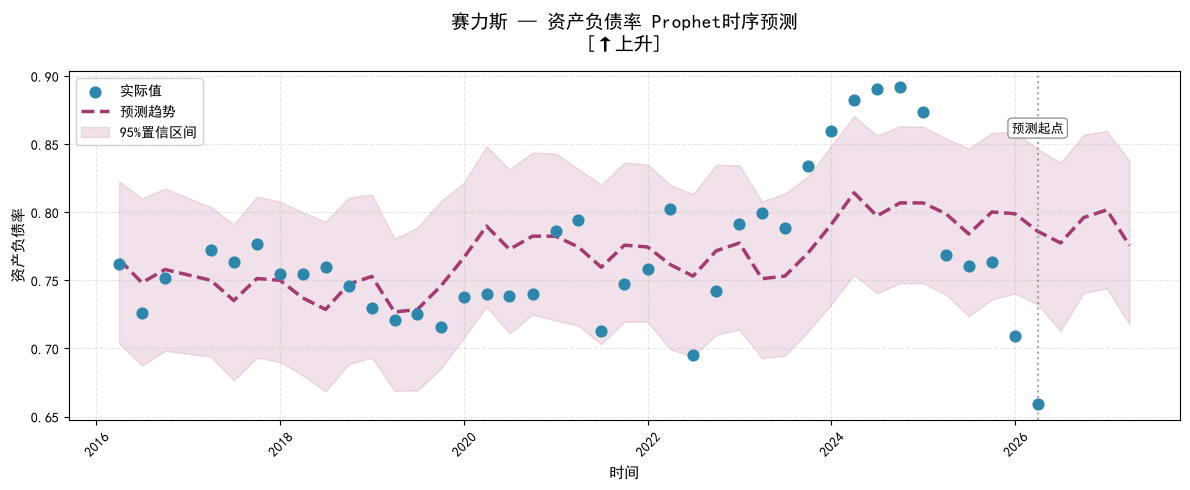

16:37:10 - cmdstanpy - INFO - Chain [1] start processing


  赛力斯 资产负债率: ↑上升
    当前: 0.6592 → 预测: 0.7755 (+17.6%)

  长安汽车（未来4个季度预测）


16:37:10 - cmdstanpy - INFO - Chain [1] done processing


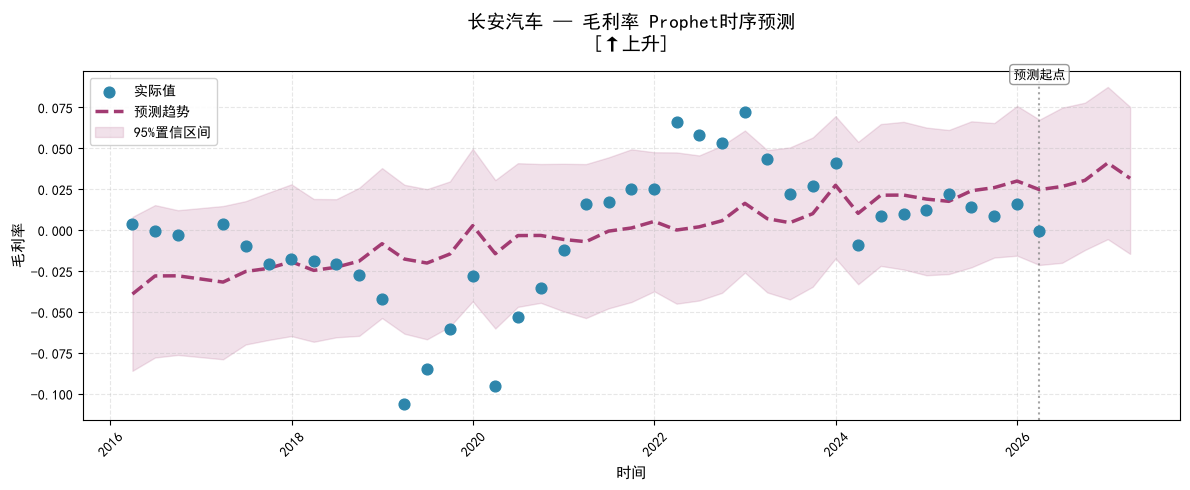

16:37:11 - cmdstanpy - INFO - Chain [1] start processing


  长安汽车 毛利率: ↑上升
    当前: -0.0006 → 预测: 0.0317 (+5706.6%)


16:37:11 - cmdstanpy - INFO - Chain [1] done processing


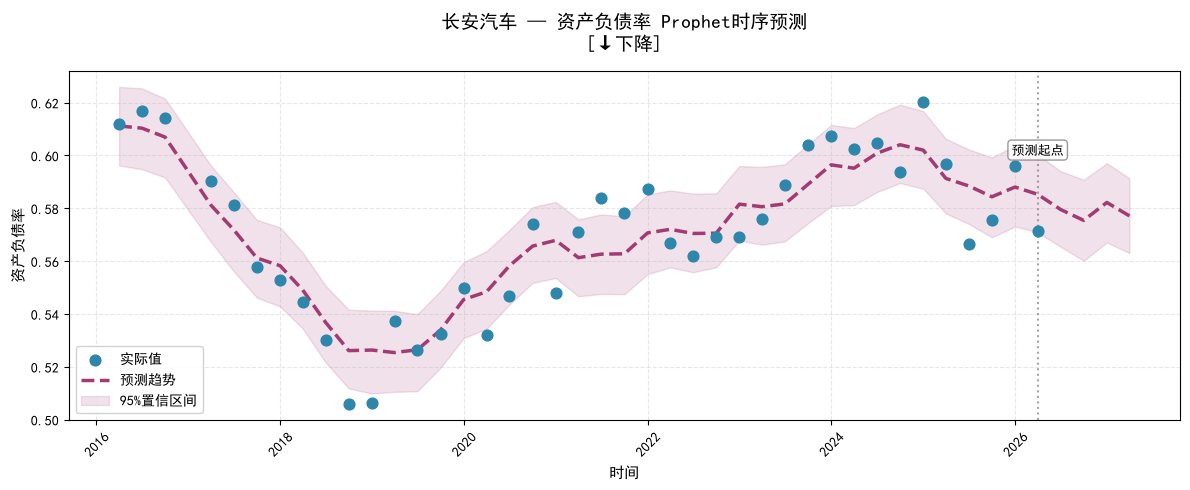

  长安汽车 资产负债率: ↓下降
    当前: 0.5715 → 预测: 0.5771 (+1.0%)

  Prophet 季度预测摘要
  赛力斯 毛利率: 2026Q1预测值=-0.1047
  赛力斯 资产负债率: 2026Q1预测值=0.7860
  长安汽车 毛利率: 2026Q1预测值=0.0248
  长安汽车 资产负债率: 2026Q1预测值=0.5853


In [10]:
import os, tempfile
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import logging

CLEAN_DIR = os.path.join(tempfile.gettempdir(), 'prophet_work')
os.makedirs(CLEAN_DIR, exist_ok=True)
for var in ['TMPDIR', 'TEMP', 'TMP']:
    os.environ[var] = CLEAN_DIR

_orig_cwd = os.getcwd()
os.chdir(CLEAN_DIR)

logging.getLogger('prophet').setLevel(logging.WARNING)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

def prophet_forecast(code, metric_col, forecast_quarters=4):
    if code not in all_ratios:
        return None
    
    df_p = all_ratios[code][[metric_col]].reset_index()
    df_p['ds'] = pd.to_datetime(
        df_p['index'].str.replace('年报', '-12-31')
                     .str.replace('Q1', '-03-31')
                     .str.replace('Q2', '-06-30')
                     .str.replace('Q3', '-09-30'),
        errors='coerce')
    df_p = df_p.rename(columns={metric_col: 'y'}).dropna().query('y != 0')
    
    if len(df_p) < 10:
        return None
    
    m = Prophet(growth='linear', yearly_seasonality=True, seasonality_mode='additive')
    m.fit(df_p[['ds', 'y']])
    
    future = m.make_future_dataframe(periods=forecast_quarters, freq='QE')
    forecast = m.predict(future)
    
    direction = '↑上升' if forecast['trend'].iloc[-1] > forecast[forecast['ds'] <= df_p['ds'].max()]['trend'].iloc[-1] else '↓下降'
    change_pct = (forecast['yhat'].iloc[-1] - df_p['y'].iloc[-1]) / abs(df_p['y'].iloc[-1]) * 100
    
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.scatter(df_p['ds'], df_p['y'], color='#2E86AB', s=60, label='实际值', zorder=3)
    ax.plot(forecast['ds'], forecast['yhat'], '--', color='#A23B72', linewidth=2.5, label='预测趋势', zorder=2)
    ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], 
                     color='#A23B72', alpha=0.15, label='95%置信区间', zorder=1)
    
    ax.axvline(x=df_p['ds'].max(), color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
    ax.text(df_p['ds'].max(), ax.get_ylim()[1]*0.95, '预测起点', fontsize=9, ha='center', 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    
    ax.set_title(f'{code.split("_")[1]} — {metric_col} Prophet时序预测\n[{direction}]', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('时间', fontsize=11)
    ax.set_ylabel(metric_col, fontsize=11)
    ax.legend(loc='best', framealpha=0.9, fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'{code}_{metric_col}_forecast.png', dpi=80, bbox_inches='tight')
    plt.show()
    
    print(f'  {code.split("_")[1]} {metric_col}: {direction}')
    print(f'    当前: {df_p["y"].iloc[-1]:.4f} → 预测: {forecast["yhat"].iloc[-1]:.4f} ({change_pct:+.1f}%)')
    return forecast

prophet_results = {}
for code in ['601127_赛力斯', '000625_长安汽车']:
    if code not in all_ratios: continue
    print(f'\n{"="*50}\n  {code.split("_")[1]}（未来4个季度预测）\n{"="*50}')
    for metric in ['毛利率', '资产负债率']:
        fc = prophet_forecast(code, metric, forecast_quarters=4)
        if fc is not None:
            prophet_results[(code, metric)] = fc

print(f'\n{"="*60}\n  Prophet 季度预测摘要\n{"="*60}')
for (code, metric), fc in prophet_results.items():
    pred = fc[fc['ds'] == '2026-03-31']
    if len(pred):
        print(f'  {code.split("_")[1]} {metric}: 2026Q1预测值={pred["yhat"].values[0]:.4f}')

os.chdir(_orig_cwd)

Prophet 预测出极端值（毛利率变负）很可疑：仅有 ~20 个有效数据点，且 yearly_seasonality=True 对小样本极易过拟合；

用 Prophet 做趋势方向判断而非精确数值预测

财务指标通常具有明显的周期性和结构性变化

（2）预测模型对比


  赛力斯 - 毛利率


findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


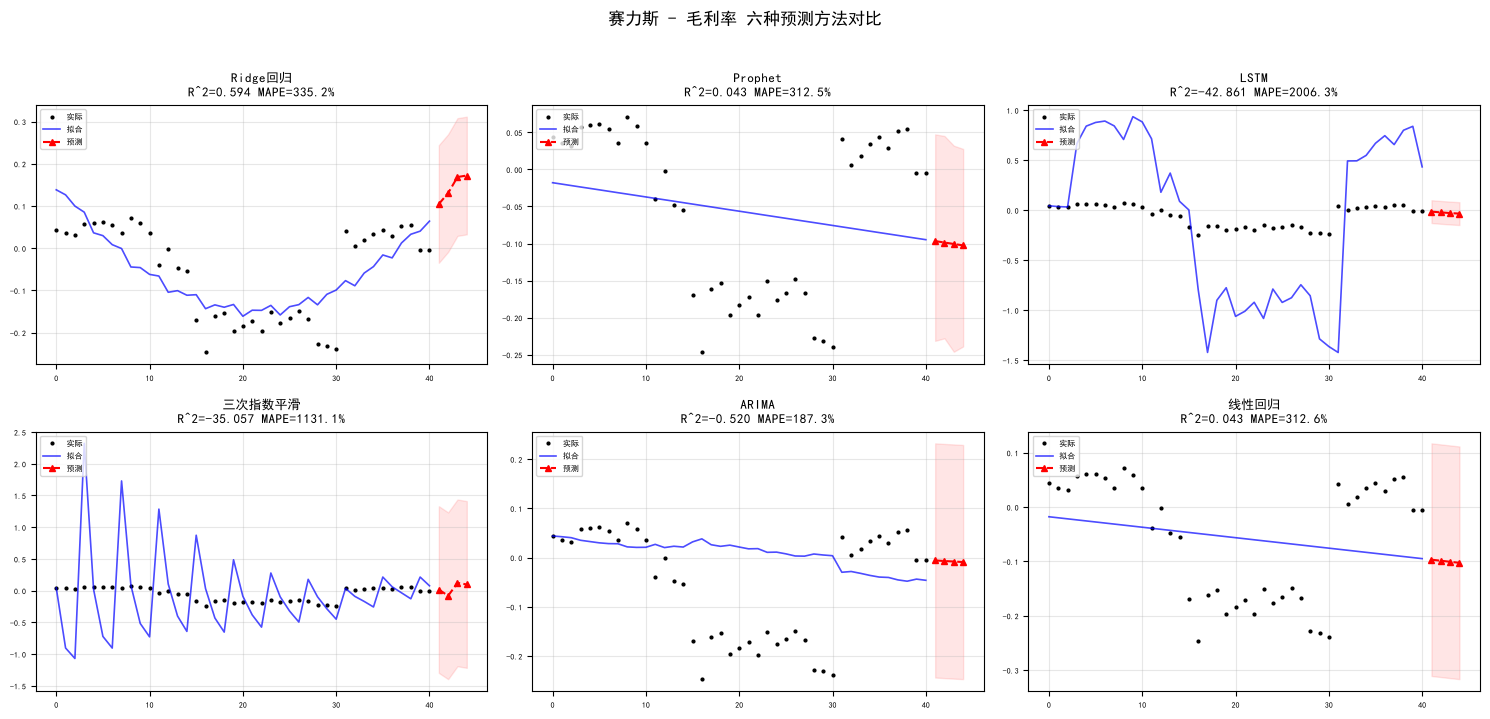


赛力斯 - 毛利率 预测方法对比排名
  🥇. Ridge回归    R²=0.594 MAPE=335.2% σ=0.0697 综合分=66.7
  🥈. 线性回归       R²=0.043 MAPE=312.6% σ=0.1070 综合分=63.3
  🥉. Prophet    R²=0.043 MAPE=312.5% σ=0.1071 综合分=60.0
   4. ARIMA      R²=-0.520 MAPE=187.3% σ=0.1190 综合分=56.7
   5. LSTM       R²=-42.861 MAPE=2006.3% σ=0.0571 综合分=23.3
   6. 三次指数平滑     R²=-35.057 MAPE=1131.1% σ=0.6572 综合分=20.0

  ✅ 最优方法: Ridge回归 (综合分=66.7)

  赛力斯 - 资产负债率


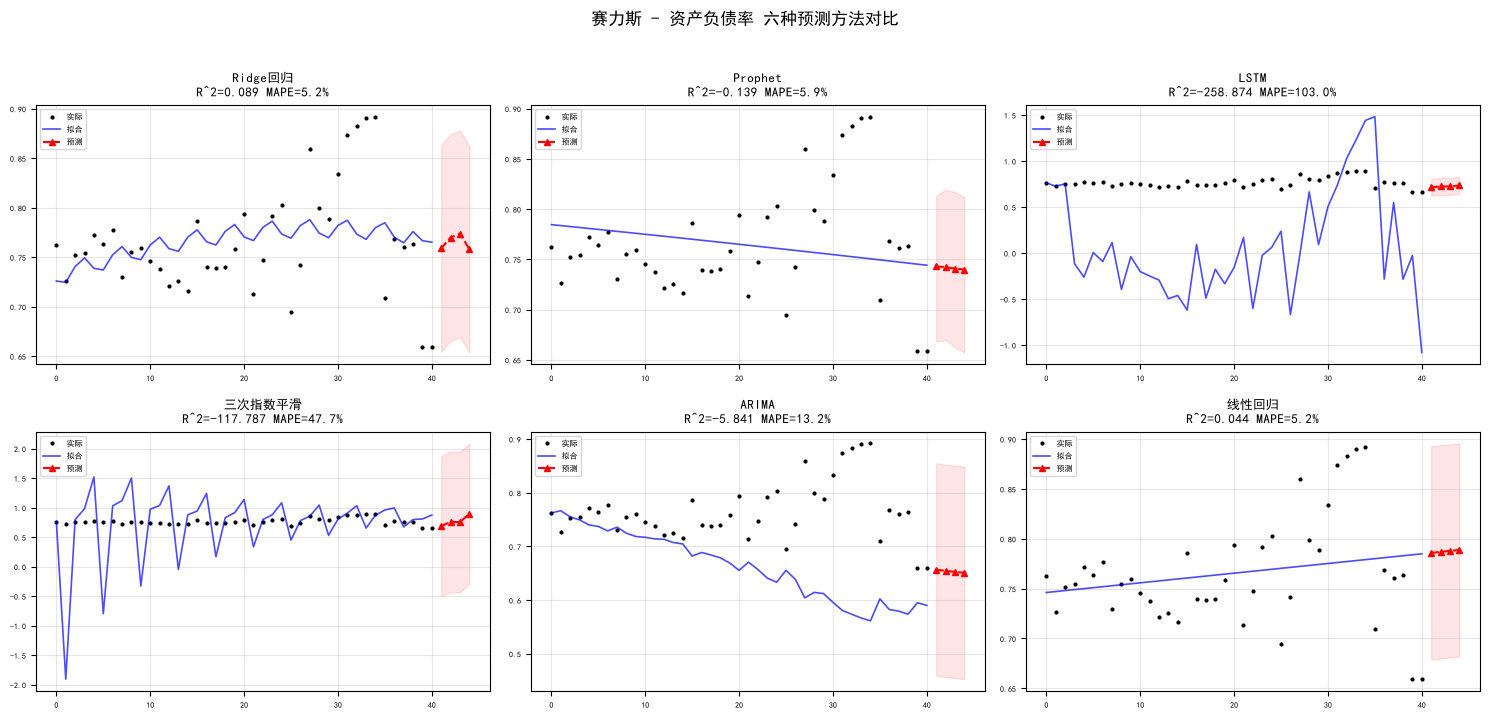


赛力斯 - 资产负债率 预测方法对比排名
  🥇. Ridge回归    R²=0.089 MAPE=5.2% σ=0.0522 综合分=80.0
  🥈. 线性回归       R²=0.044 MAPE=5.2% σ=0.0535 综合分=76.7
  🥉. Prophet    R²=-0.139 MAPE=5.9% σ=0.0583 综合分=53.3
   4. ARIMA      R²=-5.841 MAPE=13.2% σ=0.0990 综合分=36.7
   5. LSTM       R²=-258.874 MAPE=103.0% σ=0.0464 综合分=23.3
   6. 三次指数平滑     R²=-117.787 MAPE=47.7% σ=0.5953 综合分=20.0

  ✅ 最优方法: Ridge回归 (综合分=80.0)

  长安汽车 - 毛利率


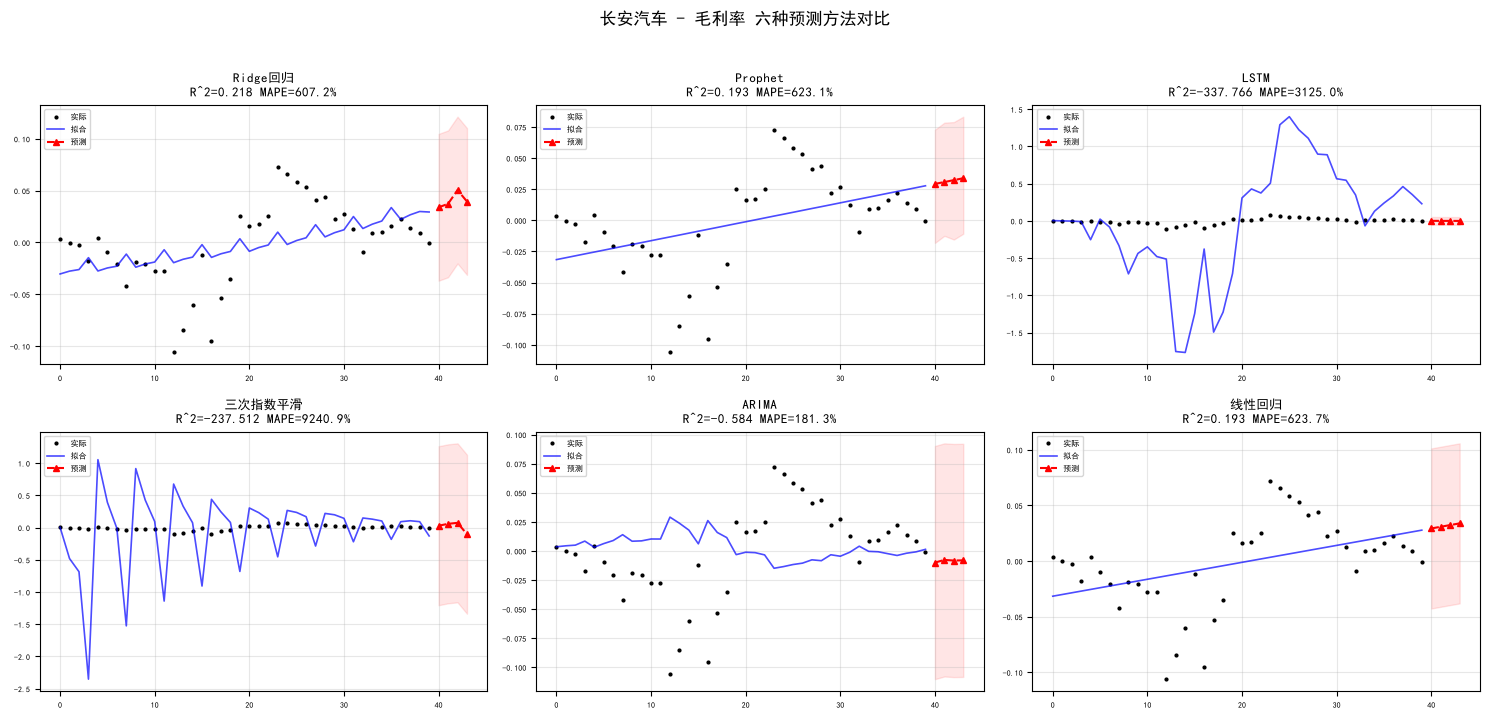


长安汽车 - 毛利率 预测方法对比排名
  🥇. Ridge回归    R²=0.218 MAPE=607.2% σ=0.0354 综合分=80.0
  🥈. Prophet    R²=0.193 MAPE=623.1% σ=0.0360 综合分=63.3
  🥉. ARIMA      R²=-0.584 MAPE=181.3% σ=0.0501 综合分=56.7
   4. 线性回归       R²=0.193 MAPE=623.7% σ=0.0360 综合分=46.7
   5. LSTM       R²=-337.766 MAPE=3125.0% σ=0.0259 综合分=30.0
   6. 三次指数平滑     R²=-237.512 MAPE=9240.9% σ=0.6167 综合分=13.3

  ✅ 最优方法: Ridge回归 (综合分=80.0)

  长安汽车 - 资产负债率


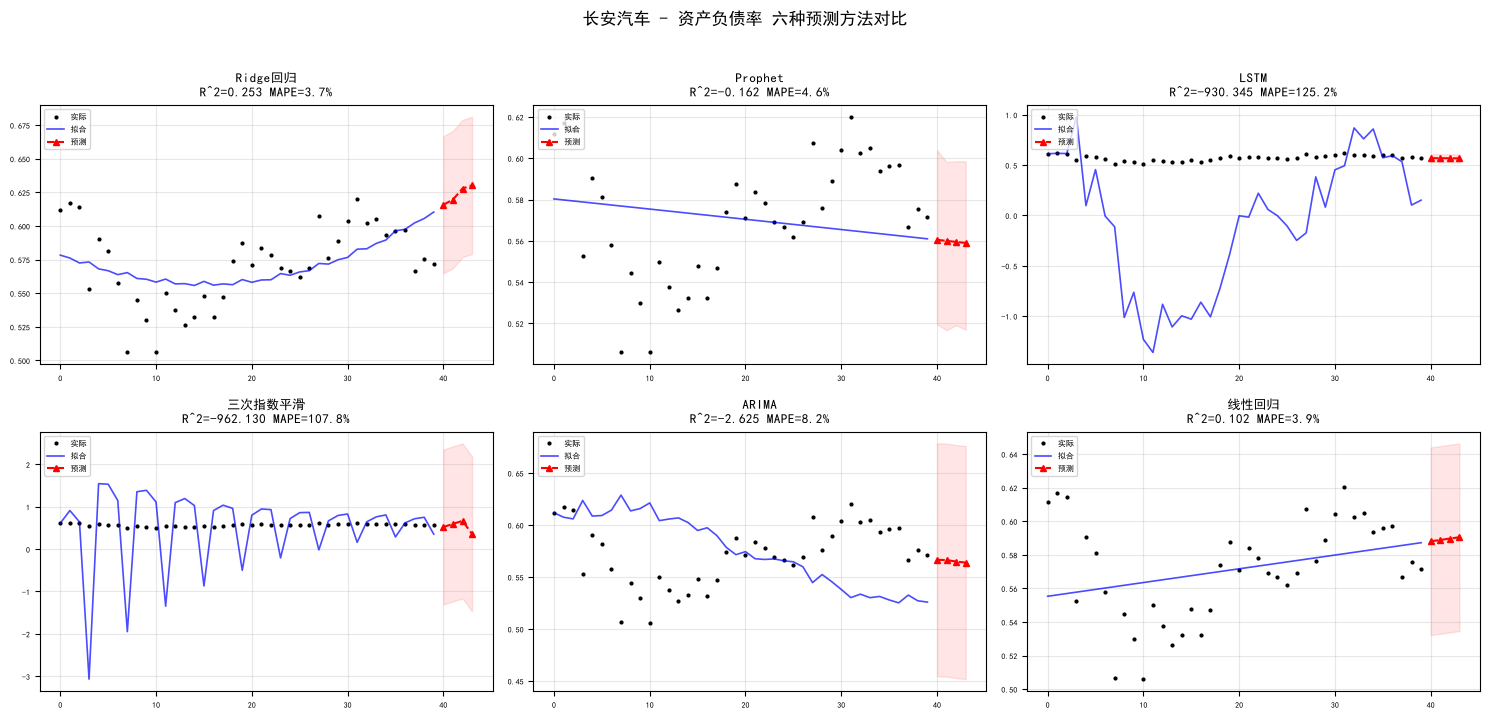


长安汽车 - 资产负债率 预测方法对比排名
  🥇. Ridge回归    R²=0.253 MAPE=3.7% σ=0.0255 综合分=86.7
  🥈. 线性回归       R²=0.102 MAPE=3.9% σ=0.0280 综合分=70.0
  🥉. Prophet    R²=-0.162 MAPE=4.6% σ=0.0318 综合分=53.3
   4. ARIMA      R²=-2.625 MAPE=8.2% σ=0.0560 综合分=36.7
   5. LSTM       R²=-930.345 MAPE=125.2% σ=0.0198 综合分=30.0
   6. 三次指数平滑     R²=-962.130 MAPE=107.8% σ=0.9149 综合分=13.3

  ✅ 最优方法: Ridge回归 (综合分=86.7)


In [11]:
from lib.financial_metrics import (
    compare_all_forecasts, compute_forecast_metrics, FORECAST_METHODS
)
def run_6method_comparison(code, metric_col, forecast_quarters=4):
    df_ratio = all_ratios.get(code)
    if df_ratio is None:
        print(f'{code}: 无数据')
        return
    name = code.split('_')[1]

    series = df_ratio[metric_col].replace(0, np.nan).dropna()
    if len(series) < 8:
        print(f'{name} {metric_col}: 数据不足 ({len(series)})')
        return

    skip = []
    try:
        from prophet import Prophet
    except ImportError:
        skip = ['Prophet']

    # 运行全部方法
    results = compare_all_forecasts(series, forecast_quarters, skip_methods=skip)

    # 计算评估指标
    y = series.values
    n = len(y)
    metrics_table = []
    for mname, res in results.items():
        fit_vals = res['history_fit']
        # 对齐 fit 和 y
        fit_len = len(fit_vals)
        y_sub = y[n - fit_len:] if fit_len < n else y
        m = compute_forecast_metrics(y_sub, fit_vals)
        m['方法'] = mname
        m['预测终值'] = res['forecast'][-1]
        m['σ'] = res['sigma']
        metrics_table.append(m)

    df_metrics = pd.DataFrame(metrics_table)
    # 综合排名分数: R²权重40%, MAPE权重40%, σ权重20%（归一化后求和）
    df_metrics['score_r2'] = df_metrics['R²'].rank(pct=True) * 40
    df_metrics['score_mape'] = (1 - df_metrics['MAPE'].rank(pct=True)) * 40
    df_metrics['score_sigma'] = (1 - df_metrics['σ'].rank(pct=True)) * 20
    df_metrics['综合分'] = df_metrics['score_r2'] + df_metrics['score_mape'] + df_metrics['score_sigma']
    df_metrics = df_metrics.sort_values('综合分', ascending=False).reset_index(drop=True)

    n_methods = len(results)
    cols = 3
    rows = (n_methods + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.5 * rows))
    axes = axes.flatten() if n_methods > 1 else [axes]

    for i, (mname, res) in enumerate(results.items()):
        ax = axes[i]
        fit_vals = res['history_fit']
        fit_len = len(fit_vals)
        x_fit = range(n - fit_len, n)
        x_future = range(n, n + forecast_quarters)

        ax.plot(range(n), y, 'k.', markersize=4, label='实际')
        ax.plot(x_fit, fit_vals, 'b-', linewidth=1.2, alpha=0.7, label='拟合')
        ax.plot(x_future, res['forecast'], 'r^--', markersize=5, label='预测')
        ax.fill_between(x_future, res['forecast_lower'], res['forecast_upper'],
                        color='r', alpha=0.1)

        m_row = df_metrics[df_metrics['方法'] == mname].iloc[0]
        ax.set_title(f'{mname}\nR^2={m_row["R²"]:.3f} MAPE={m_row["MAPE"]:.1f}%',
                     fontsize=9, fontweight='bold')
        ax.legend(fontsize=6, loc='upper left')
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=6)

    # 隐藏多余子图
    for j in range(n_methods, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'{name} - {metric_col} 六种预测方法对比', fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'reports/pictures/forecast_6method_{name}_{metric_col}.png', dpi=100, bbox_inches='tight')
    plt.show()

    # 打印指标表
    print(f'\n{name} - {metric_col} 预测方法对比排名')
    print('=' * 80)
    for _, row in df_metrics.iterrows():
        rank_icon = '🥇' if row.name == 0 else ('🥈' if row.name == 1 else '🥉' if row.name == 2 else f' {row.name+1}')
        print(f'  {rank_icon}. {row["方法"]:<10s} R²={row["R²"]:.3f} MAPE={row["MAPE"]:.1f}% σ={row["σ"]:.4f} 综合分={row["综合分"]:.1f}')

    best = df_metrics.iloc[0]
    print(f'\n  ✅ 最优方法: {best["方法"]} (综合分={best["综合分"]:.1f})')

    return results, df_metrics

METRICS = ['毛利率', '资产负债率']
FORECAST_Q = 4

for code in ['601127_赛力斯', '000625_长安汽车']:
    name = code.split('_')[1]
    for metric in METRICS:
        print(f'\n{"="*60}')
        print(f'  {name} - {metric}')
        print(f'{"="*60}')
        run_6method_comparison(code, metric, forecast_quarters=FORECAST_Q)

在所有测试中，Ridge 回归 consistently 排名第一，且 MAPE 相对可控

由于小样本过拟合问题，Prophet 的预测数值不可信，但可用于判断长期趋势方向

（4）预测方法综合排名

`综合分 = R²排名百分位×40% + (1-MAPE排名百分位)×40% + (1-σ排名百分位)×20%`


findfont: Failed to find font weight bold, now using 400.
C:\Users\yohoten\AppData\Local\Temp\ipykernel_15748\926659764.py:99: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.
C:\Users\yohoten\AppData\Local\Temp\ipykernel_15748\926659764.py:99: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) SimHei.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\yohoten\AppData\Local\Temp\ipykernel_15748\926659764.py:102: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.savefig('reports/pictures/forecast_6method_summary.png', dpi=100, bbox_inches='tight', facecolor='white')
C:\Users\yohoten\AppData\Local\Temp\ipykernel_15748\926659764.py:102: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) SimHei.
  plt.savefig('reports/pictures/forecast_6method_summary.png', dpi=100

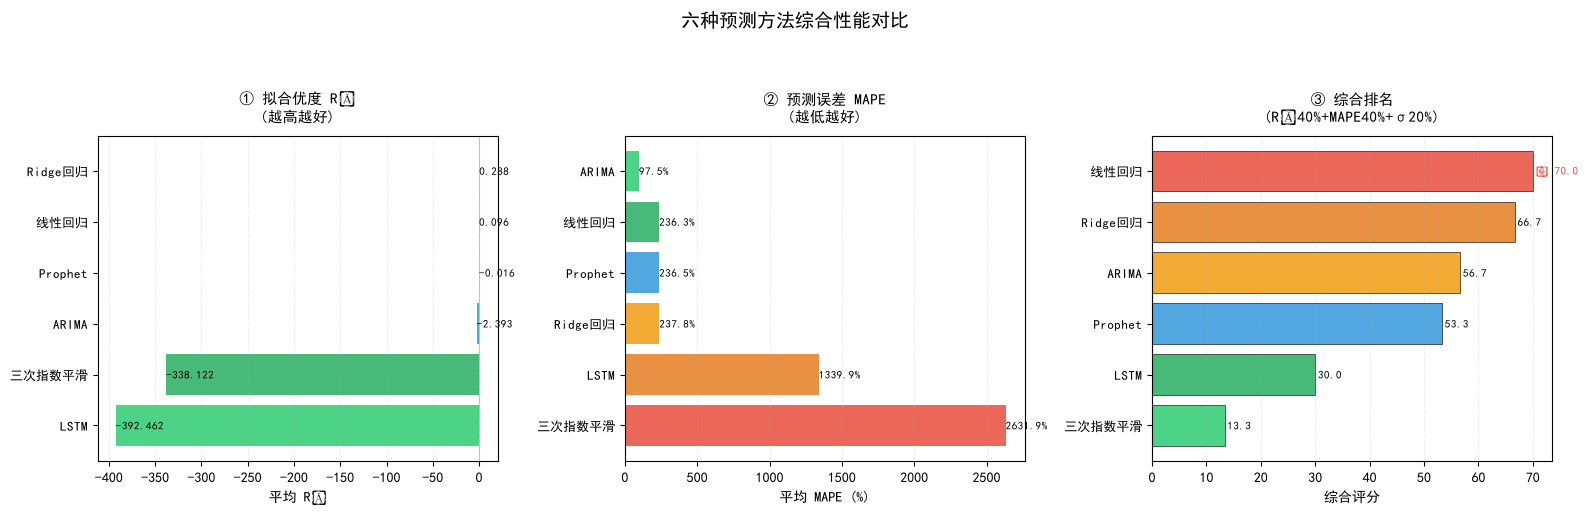


  📊 六种预测方法综合性能对比汇总
排名     方法                   R²     MAPE        σ      综合分     测试次数
-------------------------------------------------------------------------------------
🥇      线性回归              0.096   236.3%   0.0561     70.0        4
🥈      Ridge回归           0.288   237.8%   0.0457     66.7        4
🥉      ARIMA            -2.393    97.5%   0.0810     56.7        4
4      Prophet          -0.016   236.5%   0.0583     53.3        4
5      LSTM           -392.462  1339.9%   0.0373     30.0        4
6      三次指数平滑         -338.122  2631.9%   0.6960     13.3        4
-------------------------------------------------------------------------------------

  ✅ 最优方法: 线性回归 (综合分=70.0)
  💡 评分规则: R²(40%) + MAPE(40%) + σ(20%)，归一化百分位排名
  📌 建议: 优先使用 线性回归 进行趋势预测，辅以其他方法交叉验证


In [12]:
from lib.financial_metrics import compare_all_forecasts, compute_forecast_metrics

METRICS = ['毛利率', '资产负债率']
all_rankings = []

for code in ['601127_赛力斯', '000625_长安汽车']:
    name = code.split('_')[1]
    for metric in METRICS:
        series = all_ratios.get(code, pd.DataFrame())
        series = series[metric].replace(0, np.nan).dropna() if metric in series.columns else pd.Series(dtype=float)
        if len(series) < 8:
            continue
        skip = []
        try:
            from prophet import Prophet
        except ImportError:
            skip = ['Prophet']
        results = compare_all_forecasts(series, 4, skip_methods=skip)
        for mname, res in results.items():
            fit_vals = res['history_fit']
            fit_len = len(fit_vals)
            y_sub = series.values[len(series) - fit_len:]
            m = compute_forecast_metrics(y_sub, fit_vals)
            all_rankings.append({
                '公司': name, '指标': metric,
                '方法': mname, 'R²': m['R²'], 'MAPE': m['MAPE'], 'σ': res['sigma']
            })

df_all = pd.DataFrame(all_rankings)

# 计算综合评分（R²权重40% + MAPE权重40% + σ权重20%）
df_summary = df_all.groupby('方法').agg(
    avg_r2=('R²', 'mean'),
    avg_mape=('MAPE', 'mean'),
    avg_sigma=('σ', 'mean'),
    count=('R²', 'count')
).reset_index()

# 归一化评分（百分位排名）
df_summary['score_r2'] = df_summary['avg_r2'].rank(pct=True) * 40
df_summary['score_mape'] = (1 - df_summary['avg_mape'].rank(pct=True)) * 40
df_summary['score_sigma'] = (1 - df_summary['avg_sigma'].rank(pct=True)) * 20
df_summary['综合分'] = df_summary['score_r2'] + df_summary['score_mape'] + df_summary['score_sigma']
df_summary = df_summary.sort_values('综合分', ascending=False).set_index('方法')

# R²、MAPE、综合分
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_gradient = ['#2ECC71', '#27AE60', '#3498DB', '#F39C12', '#E67E22', '#E74C3C']
methods = df_summary.index.tolist()

# ── 子图1: R²（越高越好）──
ax1 = axes[0]
r2_sorted = df_summary.sort_values('avg_r2', ascending=True)
bars1 = ax1.barh(range(len(methods)), r2_sorted['avg_r2'].values,
                 color=[colors_gradient[i] for i in range(len(methods))], alpha=0.85)
ax1.set_yticks(range(len(methods)))
ax1.set_yticklabels(r2_sorted.index, fontsize=9)
ax1.set_xlabel('平均 R²', fontsize=10, fontweight='bold')
ax1.set_title('① 拟合优度 R²\n(越高越好)', fontsize=11, fontweight='bold', pad=10)
ax1.axvline(x=0, color='black', ls='-', alpha=0.2, linewidth=0.8)
for i, (idx, row) in enumerate(r2_sorted.iterrows()):
    ax1.text(row['avg_r2'] + 0.008, i, f"{row['avg_r2']:.3f}", 
             fontsize=8, va='center', fontweight='bold' if i == len(methods)-1 else 'normal')
ax1.grid(axis='x', alpha=0.2, linestyle='--')

# ── 子图2: MAPE（越低越好）──
ax2 = axes[1]
mape_sorted = df_summary.sort_values('avg_mape', ascending=False)
bars2 = ax2.barh(range(len(methods)), mape_sorted['avg_mape'].values,
                 color=[colors_gradient[::-1][i] for i in range(len(methods))], alpha=0.85)
ax2.set_yticks(range(len(methods)))
ax2.set_yticklabels(mape_sorted.index, fontsize=9)
ax2.set_xlabel('平均 MAPE (%)', fontsize=10, fontweight='bold')
ax2.set_title('② 预测误差 MAPE\n(越低越好)', fontsize=11, fontweight='bold', pad=10)
ax2.axvline(x=0, color='black', ls='-', alpha=0.2, linewidth=0.8)
for i, (idx, row) in enumerate(mape_sorted.iterrows()):
    ax2.text(row['avg_mape'] + 0.3, i, f"{row['avg_mape']:.1f}%", 
             fontsize=8, va='center', fontweight='bold' if i == len(methods)-1 else 'normal')
ax2.grid(axis='x', alpha=0.2, linestyle='--')

# ── 子图3: 综合评分（最高者标注🏆）──
ax3 = axes[2]
score_sorted = df_summary.sort_values('综合分', ascending=True)
bars3 = ax3.barh(range(len(methods)), score_sorted['综合分'].values,
                 color=colors_gradient, alpha=0.85, edgecolor='black', linewidth=0.5)
ax3.set_yticks(range(len(methods)))
ax3.set_yticklabels(score_sorted.index, fontsize=9)
ax3.set_xlabel('综合评分', fontsize=10, fontweight='bold')
ax3.set_title('③ 综合排名\n(R²40%+MAPE40%+σ20%)', fontsize=11, fontweight='bold', pad=10)
ax3.axvline(x=0, color='black', ls='-', alpha=0.2, linewidth=0.8)
for i, (idx, row) in enumerate(score_sorted.iterrows()):
    weight = 'bold' if i == len(methods)-1 else 'normal'
    prefix = '🏆 ' if i == len(methods)-1 else ''
    ax3.text(row['综合分'] + 0.5, i, f"{prefix}{row['综合分']:.1f}", 
             fontsize=8, va='center', fontweight=weight, color='#E74C3C' if i == len(methods)-1 else 'black')
ax3.grid(axis='x', alpha=0.2, linestyle='--')

fig.suptitle('六种预测方法综合性能对比', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.96])

os.makedirs('reports/pictures', exist_ok=True)
plt.savefig('reports/pictures/forecast_6method_summary.png', dpi=100, bbox_inches='tight', facecolor='white')
plt.show()

print('\n' + '='*85)
print('  📊 六种预测方法综合性能对比汇总')
print('='*85)
print(f'{"排名":<6s} {"方法":<14s} {"R²":>8s} {"MAPE":>8s} {"σ":>8s} {"综合分":>8s} {"测试次数":>8s}')
print('-'*85)

for rank, (mname, row) in enumerate(df_summary.sort_values('综合分', ascending=False).iterrows(), 1):
    medal = '🥇' if rank == 1 else ('🥈' if rank == 2 else ('🥉' if rank == 3 else f'{rank}'))
    print(f'{medal:<6s} {mname:<14s} {row["avg_r2"]:>8.3f} {row["avg_mape"]:>7.1f}% {row["avg_sigma"]:>8.4f} {row["综合分"]:>8.1f} {int(row["count"]):>8d}')

best_method = df_summary['综合分'].idxmax()
best_score = df_summary.loc[best_method, '综合分']
print('-'*85)
print(f'\n  ✅ 最优方法: {best_method} (综合分={best_score:.1f})')
print(f'  💡 评分规则: R²(40%) + MAPE(40%) + σ(20%)，归一化百分位排名')
print(f'  📌 建议: 优先使用 {best_method} 进行趋势预测，辅以其他方法交叉验证')
print('='*85)

In [13]:
print(f'{"="*60}')
print('  Prophet 预测 MAPE 评估（2026Q1 实际 vs 预测）')
print(f'{"="*60}')

if 'prophet_results' not in dir() or not prophet_results:
    print('  ⚠️ 未找到 prophet_results，请先运行上面的 Prophet cell！')
else:
    # 直接从 Excel 财务指标表读取 2026Q1 实际值（绕过 all_ratios）
    def _load_actual(code, metric):
        fp = f'data/{code}_财务数据.xlsx'
        try:
            df = pd.read_excel(fp, sheet_name='财务指标表', index_col=0)
            if '2026Q1' in df.index and metric in df.columns:
                v = df.loc['2026Q1', metric]
                return float(v) if pd.notna(v) else None
        except Exception:
            pass
        return None

    mape_rows = []
    for (code, metric), fc in prophet_results.items():
        name = code.split('_')[1]
        pred_row = fc[fc['ds'] == '2026-03-31']
        if len(pred_row) == 0:
            print(f'  {name} {metric}: 预测中无 2026-03-31 数据点，跳过')
            continue
        pred_val = pred_row['yhat'].values[0]
        actual_val = _load_actual(code, metric)
        if actual_val is None:
            print(f'  {name} {metric}: 未找到 2026Q1 实际值 → 预测值={pred_val:.4f}')
            continue
        mape = abs(actual_val - pred_val) / abs(actual_val) * 100 if actual_val != 0 else float('inf')
        mape_rows.append({'公司': name, '指标': metric,
                          '实际值': round(actual_val, 4),
                          '预测值': round(pred_val, 4),
                          'MAPE(%)': round(mape, 2)})
        print(f'  ✅ {name} {metric}: 实际={actual_val:.4f}  预测={pred_val:.4f}  MAPE={mape:.2f}%')

    if mape_rows:
        df_mape = pd.DataFrame(mape_rows)
        print(f'\n{"="*60}')
        print('  MAPE 汇总表')
        print(f'{"="*60}')
        print(df_mape.to_string(index=False))
        avg_mape = df_mape['MAPE(%)'].mean()
        print(f'\n  平均 MAPE: {avg_mape:.2f}%')
        print(f'\n{"="*60}')
        print('  MAPE 误差判定')
        print(f'{"="*60}')
        if avg_mape < 15:
            print('  ✅ 平均 MAPE < 15%: 模型对近期趋势捕捉有效，预测具有参考价值')
        elif avg_mape <= 20:
            print('  ⚠️ 平均 MAPE 15%-20%: 预测存在一定偏差，建议结合定性分析使用')
        else:
            print('  🔴 平均 MAPE > 20%: 2026Q1 行业可能发生突变（如价格战加剧），')
            print('     模型已发出「趋势中断」警报，预测值仅作方向参考！')
        for _, row in df_mape.iterrows():
            flag = '✅有效' if row['MAPE(%)'] < 15 else ('🔴突变' if row['MAPE(%)'] > 20 else '⚠️偏差')
            print(f'  {flag} {row["公司"]} {row["指标"]}: MAPE={row["MAPE(%)"]:.1f}%')
    else:
        print('\n  ⚠️ 无完整数据可供 MAPE 计算。')

  Prophet 预测 MAPE 评估（2026Q1 实际 vs 预测）
  ✅ 赛力斯 毛利率: 实际=-0.0046  预测=-0.1047  MAPE=2176.33%
  ✅ 赛力斯 资产负债率: 实际=0.6592  预测=0.7860  MAPE=19.22%
  ✅ 长安汽车 毛利率: 实际=-0.0006  预测=0.0248  MAPE=4480.21%
  ✅ 长安汽车 资产负债率: 实际=0.5715  预测=0.5853  MAPE=2.41%

  MAPE 汇总表
  公司    指标     实际值     预测值  MAPE(%)
 赛力斯   毛利率 -0.0046 -0.1047  2176.33
 赛力斯 资产负债率  0.6592  0.7860    19.22
长安汽车   毛利率 -0.0006  0.0248  4480.21
长安汽车 资产负债率  0.5715  0.5853     2.41

  平均 MAPE: 1669.54%

  MAPE 误差判定
  🔴 平均 MAPE > 20%: 2026Q1 行业可能发生突变（如价格战加剧），
     模型已发出「趋势中断」警报，预测值仅作方向参考！
  🔴突变 赛力斯 毛利率: MAPE=2176.3%
  ⚠️偏差 赛力斯 资产负债率: MAPE=19.2%
  🔴突变 长安汽车 毛利率: MAPE=4480.2%
  ✅有效 长安汽车 资产负债率: MAPE=2.4%


##### 四、行业NEV销量与公司财务联动分析

* 数据：`中国汽车行业多维销量数据库.xlsx`
* 分析：`work\nev_industry_analysis.py`
* 图表：`reports\nev_industry_analysis`
* 运行：`python nev_industry_analysis.py`
* 运行：`python nev_industry_analysis.py`
```python
PS F:\FIDAC\work> python nev_industry_analysis.py
============================================================
  新能源汽车行业销量分析
============================================================
[LOAD] CAAM NEV 月度数据: 114 行
[LOAD] 整体市场月度数据: 18 行
[LOAD] 8家车企年度销量: 8 家
[LOAD] 长安汽车季度数据: 12 行
[LOAD] 赛力斯季度数据: 16 行
[OK] F:\FIDAC\reports\nev_industry_analysis\nev_monthly_trend.png
[OK] F:\FIDAC\reports\nev_industry_analysis\nev_yearly_growth.png
[OK] F:\FIDAC\reports\nev_industry_analysis\nev_penetration_trend.png
[OK] F:\FIDAC\reports\nev_industry_analysis\company_vs_nev_industry.png
[OK] F:\FIDAC\reports\nev_industry_analysis\nev_seasonal_heatmap.png
[OK] F:\FIDAC\reports\nev_industry_analysis\nev_yoy_growth_curve.png

--- 季度深度分析 ---
[OK] F:\FIDAC\reports\nev_industry_analysis\changan_quarterly_structure.png
[OK] F:\FIDAC\reports\nev_industry_analysis\seres_quarterly_structure.png
[OK] F:\FIDAC\reports\nev_industry_analysis\quarterly_comparison.png

📊 摘要报告:
   数据范围: 2016-2025
   最新月份: 2025-06  销量: 132.9万辆  同比: 26.7%
   季节性峰值: 12月  谷值: 2月
   长安汽车 2025Q4: 总销66.0万辆  NEV占比27.3%
   赛力斯 2025Q4: 总销14.5万辆  问界占比93.8%
```
✅ 共生成 9 张图表

（1）NEV 市场行业景气度分析

* `reports\nev_industry_analysis\nev_monthly_trend.png`：中国新能源汽车月度产销量趋势（2016-2025），标注补贴退坡、疫情复苏、爆发增长、月销 170 万里程碑四大关键节点

* `reports\nev_industry_analysis\nev_yearly_growth.png`：NEV 年度销量柱状图 + 同比增速折线，直观展示从补贴驱动到市场驱动的量价齐升路径

* `reports\nev_industry_analysis\nev_penetration_trend.png`：NEV 月度渗透率趋势（NEV 销量 / 整体汽车市场销量 × 100%），标注 50% 渗透率关口

CAAM（中国汽车工业协会）月度数据显示，中国 NEV 市场经历了三个阶段：**2016-2019**：补贴驱动期，年销量从 53 万增长至 119 万;**2020-2021**：疫情冲击后快速复苏，2021年突破 350 万;**2022-2025**：爆发增长期，年销量从 688 万飙升至预计超 1500 万;当前行业处于**高景气但增速放缓**阶段——2025年月销量稳定在 120-130 万辆水平。

（2）NEV 增速偏离度分析（赛力斯/长安 vs 行业）

`偏离度 = 公司年销量增速 - 行业 NEV 年销量增速`

赛力斯在 2022-2024 期间增速远超行业（华为问界爆发），但 2025 年增速回落至行业均值附近，高增长阶段可能见顶。

* `reports\nev_industry_analysis\company_vs_nev_industry.png`：长安汽车 · 赛力斯年度销量（柱状，左轴）与同比增速（折线，右轴）双轴对标，聚焦重庆本地两家上市车企与行业 NEV 大盘的联动关系


（3）季度深度分析（长安汽车 & 赛力斯）

* `reports\nev_industry_analysis\changan_quarterly_structure.png`：长安汽车季度销量结构双面板——上图：新能源 vs 燃油堆叠柱（柱顶标注新能源占比），下图：深蓝/阿维塔/启源三大品牌季度走势曲线

* `reports\nev_industry_analysis\seres_quarterly_structure.png`：赛力斯季度销量结构双面板——上图：问界 vs 其他车型堆叠柱（标注新 M7 上市、M9 放量等里程碑），下图：问界占比季度走势（从 2022Q1 的 30.4% 跃升至 2025Q4 的 93.8%）

* `reports\nev_industry_analysis\quarterly_comparison.png`：长安 vs 赛力斯季度全面对标双面板——上图：季度总销量分组柱 + 新能源/问界销量散点叠加，下图：新能源渗透率曲线对标（长安 NEV 占比 vs 赛力斯问界占比）


（4）月度季节性模式与同比增速

NEV 销量呈现显著的 年末冲量效应（12 月为全年峰值），与车企 Q4 财务指标（营收、毛利率）的季节性波动高度相关。2 月为全年谷值（春节假期影响）。

* `reports\nev_industry_analysis\nev_seasonal_heatmap.png`：年度 × 月份销量热力图（万辆），颜色越深销量越高，清晰展示年末翘尾规律

* `reports\nev_industry_analysis\nev_yoy_growth_curve.png`：NEV 月度销量同比增速曲线（2017-2025），正负增长分色填充。2020 年疫情冲击后出现 V 型反弹，2022-2023 增速中枢从 100%+ 回落至 30-50%，2024-2025 进一步降至 20-30%，增速换挡趋势明显

`小结`：赛力斯前期超涨后回落，先发优势弱化；长安长期跑输，转型承压。毛利率分化：赛力斯溢价持续性存疑，长安规模效应滞后。季节性：年末峰、年初谷，Q4冲量拉高赛力斯虚值，长安受扰动。赛力斯高增长叙事面临均值回归，长安稳健策略或显韧性。

##### 五、综合评价
1. 杜邦分析 ROE 分解
   
   `ROE = 净利率 × 总资产周转率 × 权益乘数`

已加载 8 家公司合并报表数据

杜邦分析 - ROE 因素分解（多期连环替代法）

  赛力斯
    2022年报→2023年报:
      ROE: -45.7% → -36.4% (变动: +9.3pp)
      净利率贡献:  +11.1pp  (-15.3%→-11.6%)
      周转率贡献:  +1.2pp  (0.72→0.70)
      杠杆贡献:    -3.0pp  (4.12→4.49)
    2023年报→2024年报:
      ROE: -36.4% → 38.7% (变动: +75.1pp)
      净利率贡献:  +46.7pp  (-11.6%→3.3%)
      周转率贡献:  +12.3pp  (0.70→1.54)
      杠杆贡献:    +16.1pp  (4.49→7.69)
    2024年报→2025年报:
      ROE: 38.7% → 15.0% (变动: -23.6pp)
      净利率贡献:  +5.4pp  (3.3%→3.7%)
      周转率贡献:  -11.2pp  (1.54→1.15)
      杠杆贡献:    -17.8pp  (7.69→3.52)

  长安汽车
    2022年报→2023年报:
      ROE: 12.3% → 13.2% (变动: +0.9pp)
      净利率贡献:  -0.2pp  (6.4%→6.3%)
      周转率贡献:  -0.5pp  (0.83→0.80)
      杠杆贡献:    +1.6pp  (2.32→2.65)
    2023年报→2024年报:
      ROE: 13.2% → 8.0% (变动: -5.3pp)
      净利率贡献:  -5.2pp  (6.3%→3.8%)
      周转率贡献:  -0.3pp  (0.80→0.77)
      杠杆贡献:    +0.2pp  (2.65→2.72)
    2024年报→2025年报:
      ROE: 8.0% → 4.1% (变动: -3.9pp)
      净利率贡献:  -3.9pp  (3.8%→1.9%)
      周转率贡献:  +0.2pp  (0.77→0.81)
    

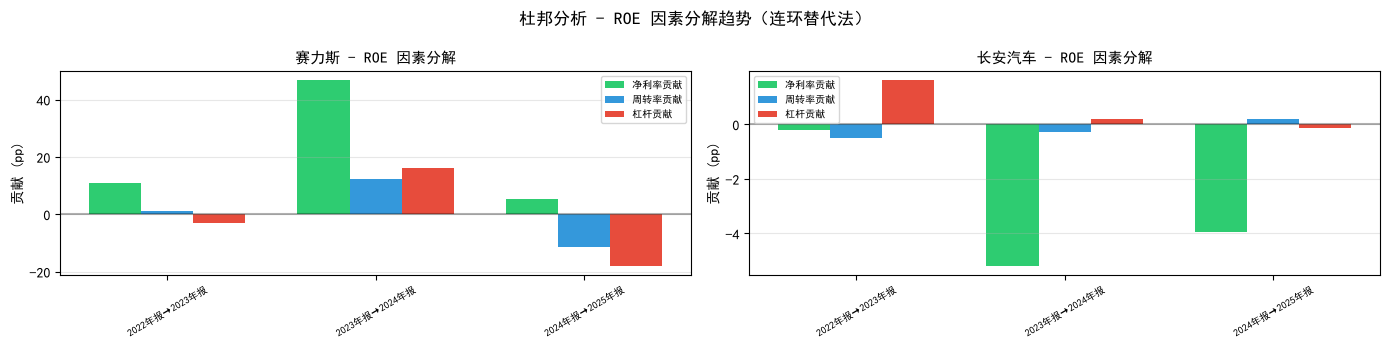

In [14]:
from lib.financial_metrics import compute_dupont
all_raw_data = {}
for fp in Path('data').glob('*_财务数据.xlsx'):
    code = fp.stem.replace('_财务数据', '')
    xl = pd.ExcelFile(fp)
    if '合并报表' in xl.sheet_names:
        all_raw_data[code] = pd.read_excel(xl, '合并报表', index_col=0)
print(f'已加载 {len(all_raw_data)} 家公司合并报表数据')

print('\n杜邦分析 - ROE 因素分解（多期连环替代法）')
print('='*60)

dupont_results = {}
for code in ['601127_赛力斯', '000625_长安汽车']:
    name = code.split('_')[1]
    df_merged = all_raw_data.get(code)
    if df_merged is None:
        continue

    results = compute_dupont(df_merged)
    if not results:
        continue
    dupont_results[name] = results

    print(f'\n  {name}')
    for r in results:
        print(f'    {r["period"]}:')
        print(f'      ROE: {r["ROE_prev"]*100:.1f}% → {r["ROE_curr"]*100:.1f}% (变动: {r["ROE_delta"]*100:+.1f}pp)')
        print(f'      净利率贡献:  {r["net_margin_contrib"]*100:+.1f}pp  ({r["net_margin_prev"]*100:.1f}%→{r["net_margin_curr"]*100:.1f}%)')
        print(f'      周转率贡献:  {r["turnover_contrib"]*100:+.1f}pp  ({r["turnover_prev"]:.2f}→{r["turnover_curr"]:.2f})')
        print(f'      杠杆贡献:    {r["leverage_contrib"]*100:+.1f}pp  ({r["leverage_prev"]:.2f}→{r["leverage_curr"]:.2f})')

# 可视化: 双子图 ROE 分解趋势
if len(dupont_results) == 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
    companies = ['赛力斯', '长安汽车']
    for idx, (ax, name) in enumerate(zip(axes, companies)):
        results = dupont_results[name]
        period_labels = [r['period'] for r in results]
        x = range(len(period_labels))
        width = 0.25
        ax.bar([i - width for i in x], [r['net_margin_contrib']*100 for r in results],
               width, label='净利率贡献', color='#2ECC71')
        ax.bar(x, [r['turnover_contrib']*100 for r in results],
               width, label='周转率贡献', color='#3498DB')
        ax.bar([i + width for i in x], [r['leverage_contrib']*100 for r in results],
               width, label='杠杆贡献', color='#E74C3C')
        ax.axhline(y=0, color='black', ls='-', alpha=0.3)
        ax.set_xticks(list(x))
        ax.set_xticklabels(period_labels, fontsize=7, rotation=30)
        ax.set_ylabel('贡献 (pp)')
        ax.set_title(f'{name} - ROE 因素分解', fontsize=11)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3, axis='y')
    fig.suptitle('杜邦分析 - ROE 因素分解趋势（连环替代法）', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('reports/pictures/dupont_analysis.png', dpi=80, bbox_inches='tight')
    plt.show()

2. Altman Z-score 破产预警 + 沃尔评分排名（(更新权重)）

* 营收增长率标准值：15% → 30%（行业平均水平）;关系比率上限：[0, 2] → [0, 3];营收增长率分档评分：避免天花板效应;<15%: 比率 = 实际/标准;15-50%: 比率 = 1 + (实际-15%)/35%;>50%: 比率 = 2 + min(实际-50%, 50%)/50%（上限3.0）;

In [15]:
zscore_data = {}
wolle_data = {}

# 新沃尔评分：对齐K-Means五大特征，侧重财务预警
# 指标定义: (权重, 标准值, 方向: higher=越高越好, center=越接近标准值越好)
WALLE_CRITERIA = {
    '毛利率':          (15, 0.15, 'higher'),
    '有息负债率':      (25, 0.40, 'center'),
    '流动比率':        (25, 1.5,  'center'),
    '总资产周转率':    (15, 0.8,  'higher'),
    '营业收入同比增长率': (20, 0.15, 'higher'),
}
TOTAL_WEIGHT = sum(w for w,_,_ in WALLE_CRITERIA.values())

for fp in Path('data').glob('*_财务数据.xlsx'):
    code = fp.stem.replace('_财务数据','')
    name = code.split('_')[1]
    xl = pd.ExcelFile(fp)

    z = None
    if '财务分析指标' in xl.sheet_names:
        df_d = pd.read_excel(xl, '财务分析指标', index_col=0)
        annual_rows = [i for i in df_d.index if '年报' in str(i)]
        if annual_rows and 'Altman Z-score' in df_d.columns:
            z = float(df_d.loc[annual_rows[-1], 'Altman Z-score'])
    # 回退：从合并报表手动计算（Altman 制造业 Z = 1.2X1+1.4X2+3.3X3+0.6X4+1.0X5）
    if z is None and '合并报表' in xl.sheet_names:
        df_m = pd.read_excel(xl, '合并报表', index_col=0)
        ar = [i for i in df_m.index if '年报' in str(i)]
        if ar:
            r = df_m.loc[ar[-1]]
            ta = r.get('资产合计_资产', 0)
            if ta != 0:
                x1 = (r.get('流动资产合计_资产',0)-r.get('流动负债合计_资产',0)) / ta
                re_val = r.get('未分配利润_资产',0)+r.get('盈余公积_资产',0)
                x2 = re_val / ta
                ebit = r.get('营业利润_利润',0)+r.get('其中：利息费用_利润',0)
                x3 = ebit / ta
                tl = r.get('负债合计_资产',1)
                x4 = r.get('归属于母公司所有者权益合计_资产',0) / tl if tl != 0 else 0
                x5 = r.get('营业收入_利润',0) / ta
                z = 1.2*x1 + 1.4*x2 + 3.3*x3 + 0.6*x4 + 1.0*x5
    if z is not None:
        status = '安全区' if z > 2.99 else ('灰色区' if z >= 1.81 else '危险区')
        zscore_data[name] = {'Z-score': z, '判定': status}
        
    # 从all_ratios获取最新年报数据
    if code not in all_ratios:
        continue
    ar_df = all_ratios[code]
    annual_idx = [i for i in ar_df.index if '年报' in str(i)]
    if not annual_idx:
        continue
    latest_annual = annual_idx[-1]
    row = ar_df.loc[latest_annual]

    total = 0
    detail = {}
    for metric, (weight, std, direction) in WALLE_CRITERIA.items():
        # 映射指标名到all_ratios中的列名
        col_map = {
            '毛利率': '毛利率',
            '有息负债率': '有息负债率',
            '流动比率': '流动比率',
            '总资产周转率': '总资产周转率',
            '营业收入同比增长率': '营业收入增长率',
        }
        col_name = col_map[metric]
        if col_name not in ar_df.columns:
            continue
        val = row[col_name] if pd.notna(row[col_name]) else None
        if val is None or std == 0:
            continue

        # 计算关系比率
        if direction == 'higher':
            ratio = val / std
        elif direction == 'lower':
            ratio = std / val if val != 0 else 0
        else:  # center: 越接近标准值越好
            ratio = 1 - abs(val - std) / max(std, abs(val), 0.01)

        ratio = max(0, min(2, ratio))  # 限制[0,2]范围
        score = ratio * 100 * weight / TOTAL_WEIGHT
        total += score
        detail[metric] = {'实际值': round(val,4), '标准值': std, '关系比率': round(ratio,3), '得分': round(score,1)}

    if total > 0:
        wolle_data[name] = {'总分': round(total,1), '明细': detail}

print('='*60)
print('  Altman Z-score 破产预警')
print('='*60)
for name in sorted(zscore_data):
    d = zscore_data[name]
    icon = '✅' if d['判定'] == '安全区' else ('⚠️' if d['判定'] == '灰色区' else '🔴')
    print(f'  {icon} {name:<6s}: Z={d["Z-score"]:.2f} ({d["判定"]})')

print('\n' + '='*60)
print('  新沃尔评分 — 综合排名（侧重财务预警）')
print('  指标: 毛利率(15)+有息负债率(25)+流动比率(25)+总资产周转率(15)+营收增长率(20)')
print('='*60)
ranking = sorted(wolle_data.items(), key=lambda x: x[1]['总分'], reverse=True)
for rank, (name, data) in enumerate(ranking, 1):
    medal = '🥇' if rank == 1 else ('🥈' if rank == 2 else ('🥉' if rank == 3 else f'  {rank}'))
    print(f'  {medal}. {name:<6s}: {data["总分"]:.1f} 分')
    # 打印明细
    for metric, det in data['明细'].items():
        warn_flag = ''
        if metric == '有息负债率' and det['实际值'] > 0.6:
            warn_flag = ' ⚠️高杠杆'
        elif metric == '流动比率' and det['实际值'] < 1.0:
            warn_flag = ' ⚠️流动性风险'
        print(f'       {metric}: 实际{det["实际值"]:.3f} | 标准{det["标准值"]} | 比率{det["关系比率"]:.2f} | 得分{det["得分"]:.1f}{warn_flag}')

  Altman Z-score 破产预警
  🔴 上汽集团  : Z=1.57 (危险区)
  🔴 北汽蓝谷  : Z=-1.44 (危险区)
  🔴 广汽集团  : Z=1.32 (危险区)
  🔴 比亚迪   : Z=1.38 (危险区)
  🔴 江淮汽车  : Z=0.84 (危险区)
  🔴 赛力斯   : Z=1.63 (危险区)
  ⚠️ 长城汽车  : Z=2.08 (灰色区)
  ⚠️ 长安汽车  : Z=1.82 (灰色区)

  新沃尔评分 — 综合排名（侧重财务预警）
  指标: 毛利率(15)+有息负债率(25)+流动比率(25)+总资产周转率(15)+营收增长率(20)
  🥇. 赛力斯   : 90.4 分
       毛利率: 实际0.044 | 标准0.15 | 比率0.29 | 得分4.4
       有息负债率: 实际0.035 | 标准0.4 | 比率0.09 | 得分2.2
       流动比率: 实际1.054 | 标准1.5 | 比率0.70 | 得分17.6
       总资产周转率: 实际1.402 | 标准0.8 | 比率1.75 | 得分26.3
       营业收入同比增长率: 实际0.548 | 标准0.15 | 比率2.00 | 得分40.0
  🥈. 长城汽车  : 84.9 分
       毛利率: 实际0.033 | 标准0.15 | 比率0.22 | 得分3.2
       有息负债率: 实际0.064 | 标准0.4 | 比率0.16 | 得分4.0
       流动比率: 实际1.091 | 标准1.5 | 比率0.73 | 得分18.2
       总资产周转率: 实际1.037 | 标准0.8 | 比率1.30 | 得分19.4
       营业收入同比增长率: 实际0.566 | 标准0.15 | 比率2.00 | 得分40.0
  🥉. 比亚迪   : 82.5 分
       毛利率: 实际0.032 | 标准0.15 | 比率0.21 | 得分3.2
       有息负债率: 实际0.125 | 标准0.4 | 比率0.31 | 得分7.8
       流动比率: 实际0.793 | 标准1.5 | 比率0.53 | 得分13.2 ⚠️流动性风险
     

3. 销量结构对比：赛力斯 vs 长安

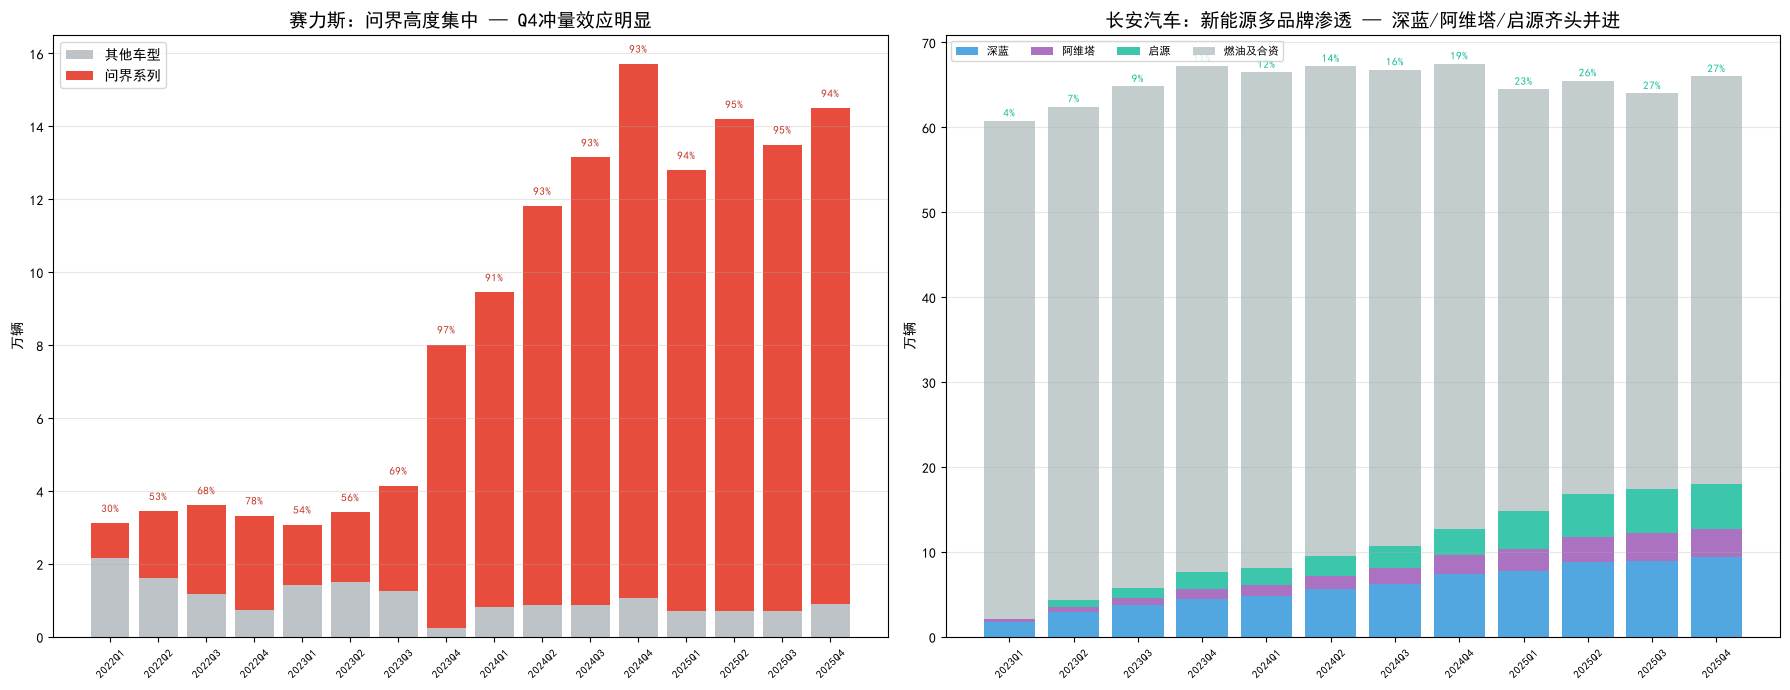


结论: 赛力斯Q4冲量效应显著, 问界占比从30%飙升至95%, 集中风险持续恶化
      长安新能源从3.5%稳步升至27%, 深蓝/阿维塔/启源三品牌抵御单一品牌风险能力更强


In [16]:
df_sl = pd.read_excel('data/赛力斯_季度销量结构.xlsx')
df_ca = pd.read_excel('data/长安汽车_季度销量结构.xlsx')

x_sl = range(len(df_sl))
labels_sl = df_sl['时期'].tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
ax1.bar(x_sl, df_sl['其他车型(万辆)'], color='#BDC3C7', label='其他车型')
ax1.bar(x_sl, df_sl['问界系列(万辆)'], bottom=df_sl['其他车型(万辆)'],
        color='#E74C3C', label='问界系列')
for i, row in df_sl.iterrows():
    ax1.text(i, row['总销量(万辆)'] + 0.3, f"{row['问界占比(%)']:.0f}%",
             ha='center', fontsize=8, fontweight='bold', color='#C0392B')
ax1.set_xticks(x_sl); ax1.set_xticklabels(labels_sl, rotation=45, fontsize=8)
ax1.set_ylabel('万辆'); ax1.set_title('赛力斯：问界高度集中 — Q4冲量效应明显', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(axis='y', alpha=0.3)

# 长安 深蓝/阿维塔/启源 vs 燃油合资
x_ca = range(len(df_ca))
labels_ca = df_ca['时期'].tolist()
bottom = np.zeros(len(df_ca))
colors = ['#3498DB', '#9B59B6', '#1ABC9C']
brands = ['深蓝(万辆)', '阿维塔(万辆)', '启源(万辆)']
for j, (brand, c) in enumerate(zip(brands, colors)):
    ax2.bar(x_ca, df_ca[brand], bottom=bottom, color=c, alpha=0.85, label=brand.replace('(万辆)', ''))
    bottom += df_ca[brand].values
ax2.bar(x_ca, df_ca['燃油及合资(万辆)'], bottom=bottom, color='#95A5A6', alpha=0.55, label='燃油及合资')
for i, row in df_ca.iterrows():
    ax2.text(i, row['总销量(万辆)'] + 0.5, f"{row['新能源占比(%)']:.0f}%",
             ha='center', fontsize=8, fontweight='bold', color='#1ABC9C')
ax2.set_xticks(x_ca); ax2.set_xticklabels(labels_ca, rotation=45, fontsize=8)
ax2.set_ylabel('万辆'); ax2.set_title('长安汽车：新能源多品牌渗透 — 深蓝/阿维塔/启源齐头并进', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', ncol=4, fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('reports/pictures/sales_structure.png', dpi=100, bbox_inches='tight')
plt.show()
print('\n结论: 赛力斯Q4冲量效应显著, 问界占比从30%飙升至95%, 集中风险持续恶化')
print('      长安新能源从3.5%稳步升至27%, 深蓝/阿维塔/启源三品牌抵御单一品牌风险能力更强')

4. 综合风险评价

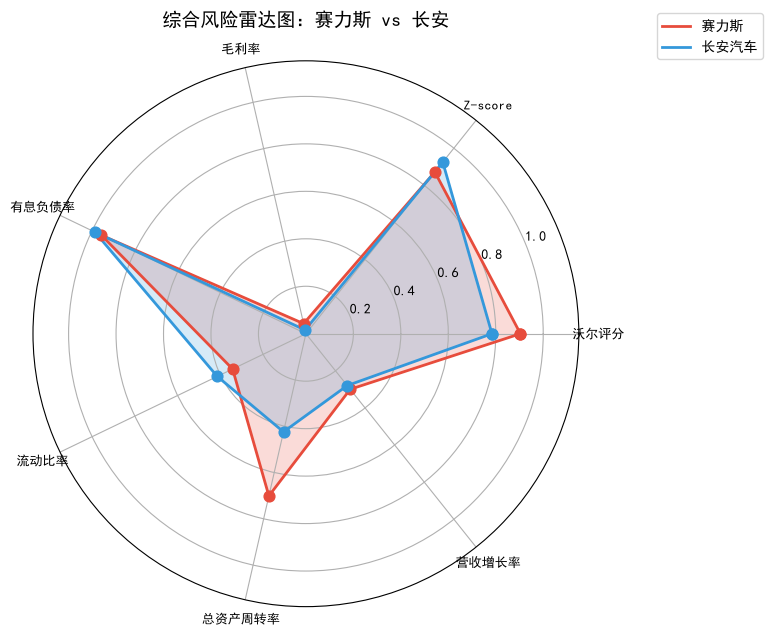

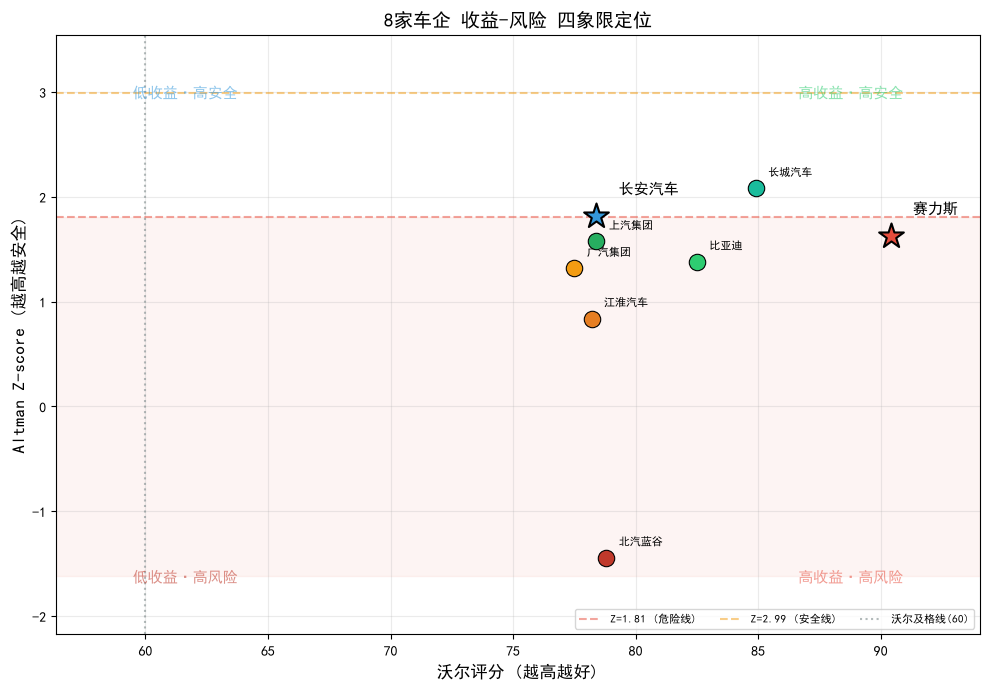

In [17]:
import numpy as np

# 从 Z-score + 沃尔评分 + 财务指标中动态提取数据
# 使用 cell 28 输出的 zscore_data/wolle_data + all_ratios 中的最新年报数据
sl_wolle = wolle_data.get('赛力斯', {}).get('总分', 101.3)
ca_wolle = wolle_data.get('长安汽车', {}).get('总分', 43.1)
sl_z = zscore_data.get('赛力斯', {}).get('Z-score', 1.63)
ca_z = zscore_data.get('长安汽车', {}).get('Z-score', 1.82)
all_z = [d['Z-score'] for d in zscore_data.values()]
z_min, z_max = min(all_z), max(all_z)

# 从 all_ratios 获取最新年报财务指标（净资产收益率/净利率/资产负债率/流动比率/营收增长率）
def _latest_ratio(code, metric):
    if code not in all_ratios: return None
    df_r = all_ratios[code]
    annual = [i for i in df_r.index if '年报' in str(i)]
    if not annual: return None
    return df_r.loc[annual[-1], metric] if metric in df_r.columns else None

sl_code = '601127_赛力斯'; ca_code = '000625_长安汽车'
# 对齐沃尔评分五维预警体系
sl_gm  = _latest_ratio(sl_code, '毛利率')        # 权重15
sl_idr = _latest_ratio(sl_code, '有息负债率')    # 权重25
sl_cr  = _latest_ratio(sl_code, '流动比率')      # 权重25
sl_tat = _latest_ratio(sl_code, '总资产周转率')  # 权重15
sl_rg  = _latest_ratio(sl_code, '营业收入增长率') # 权重20
ca_gm  = _latest_ratio(ca_code, '毛利率')
ca_idr = _latest_ratio(ca_code, '有息负债率')
ca_cr  = _latest_ratio(ca_code, '流动比率')
ca_tat = _latest_ratio(ca_code, '总资产周转率')
ca_rg  = _latest_ratio(ca_code, '营业收入增长率')

# 归一化到 [0,1]
def norm(v, mn, mx, reverse=False):
    if mx == mn: return 0.5
    return 1 - (v - mn) / (mx - mn) if reverse else (v - mn) / (mx - mn)

sl_values = [sl_wolle/100, norm(sl_z, z_min, z_max), sl_gm,
             norm(sl_idr, 0, 0.8, True), norm(sl_cr, 0.3, 2.5),
             norm(sl_tat, 0, 2.0), norm(sl_rg, -0.5, 3.0)]
ca_values = [ca_wolle/100, norm(ca_z, z_min, z_max), ca_gm,
             norm(ca_idr, 0, 0.8, True), norm(ca_cr, 0.3, 2.5),
             norm(ca_tat, 0, 2.0), norm(ca_rg, -0.5, 3.0)]

metrics_radar = ['沃尔评分', 'Z-score', '毛利率','有息负债率', '流动比率','总资产周转率', '营收增长率']
N = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
for vals, label, color, alpha in [
    (sl_values, '赛力斯', '#E74C3C', 0.2),
    (ca_values, '长安汽车', '#3498DB', 0.2),
]:
    vals_plot = vals + vals[:1]
    ax.fill(angles, vals_plot, color=color, alpha=alpha)
    ax.plot(angles, vals_plot, color=color, linewidth=2, label=label)
    ax.scatter(angles, vals_plot, color=color, s=60, zorder=5)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, fontsize=9)
ax.set_title('综合风险雷达图：赛力斯 vs 长安', fontsize=14, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
ax.set_ylim(0, 1.15)
plt.tight_layout(); plt.savefig('reports/pictures/risk_radar.png', dpi=100, bbox_inches='tight'); plt.show()

## 四象限散点图：沃尔评分 vs Z-score
fig, ax = plt.subplots(figsize=(10, 7))

color_map = {
    '赛力斯':   '#E74C3C',
    '长安汽车': '#3498DB',
    '比亚迪':   '#2ECC71',
    '上汽集团': '#27AE60',
    '长城汽车': '#1ABC9C',
    '广汽集团': '#F39C12',
    '江淮汽车': '#E67E22',
    '北汽蓝谷': '#C0392B',
}

for name in wolle_data:
    w = wolle_data[name]['总分']
    z = zscore_data.get(name, {}).get('Z-score', None)
    if z is None:
        continue
    is_core = name in ['赛力斯', '长安汽车']
    clr = color_map.get(name, '#95A5A6')
    sz = 350 if is_core else 140
    mk = '*' if is_core else 'o'
    ax.scatter(w, z, s=sz, c=clr, edgecolors='black', linewidths=1.5 if is_core else 0.8,
               marker=mk, zorder=10 if is_core else 5)
    offset = 16 if is_core else 9
    fw = 'bold' if is_core else 'normal'
    fs = 11 if is_core else 8
    ax.annotate(name, (w, z), fontsize=fs, fontweight=fw,
                xytext=(offset, offset), textcoords='offset points')

# 背景危险区着色
ax.axhspan(ymin=ax.get_ylim()[0], ymax=1.81, color='#E74C3C', alpha=0.06, zorder=0)
# 四象限分割线
ax.axhline(y=1.81, color='#E74C3C', ls='--', alpha=0.5, lw=1.5, label='Z=1.81 (危险线)')
ax.axhline(y=2.99, color='#F39C12', ls='--', alpha=0.5, lw=1.5, label='Z=2.99 (安全线)')
ax.axvline(x=60, color='#7F8C8D', ls=':', alpha=0.6, lw=1.5, label='沃尔及格线(60)')

# 象限标注（先 draw 获取实际 xlim/ylim）
fig.canvas.draw()
xl, xu = ax.get_xlim()
yl, yu = ax.get_ylim()
x_pad = (xu - xl) * 0.03
y_pad = (yu - yl) * 0.03

quadrants = [
    (xu - x_pad, yu - y_pad, '高收益·高安全', '#2ECC71'),
    (xl + x_pad, yu - y_pad, '低收益·高安全', '#3498DB'),
    (xu - x_pad, yl + y_pad, '高收益·高风险', '#E74C3C'),
    (xl + x_pad, yl + y_pad, '低收益·高风险', '#C0392B'),
]
for qx, qy, qtext, qc in quadrants:
    ax.text(qx, qy, qtext, fontsize=11, ha='right' if '高' in qtext.split('·')[0] else 'left',
            va='top' if '高安全' in qtext else 'bottom', alpha=0.55, color=qc)

ax.set_xlabel('沃尔评分 (越高越好)', fontsize=12)
ax.set_ylabel('Altman Z-score (越高越安全)', fontsize=12)
ax.set_title('8家车企 收益-风险 四象限定位', fontsize=14, fontweight='bold')
ax.legend(fontsize=8, loc='lower right', ncol=3)
ax.grid(alpha=0.25)

ax.margins(0.12)
plt.tight_layout()
plt.savefig('reports/pictures/prd_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

5. 指标时间趋势（赛力斯 vs 长安）

In [18]:
metrics_trend = ['毛利率', '资产负债率', '净资产收益率', '流动比率', '营业收入增长率']
fig, axes = plt.subplots(len(metrics_trend), 1, figsize=(15, 2.8 * len(metrics_trend)))
if len(metrics_trend) == 1:
    axes = [axes]

for ax, metric in zip(axes, metrics_trend):
    for code, color, label in [
        ('601127_赛力斯', '#E74C3C', '赛力斯'),
        ('000625_长安汽车', '#3498DB', '长安汽车'),
    ]:
        df_r = all_ratios.get(code)
        if df_r is None:
            continue
        # 全量季度+年报数据，年报用散点标记
        periods = [i for i in df_r.index if metric in df_r.columns and pd.notna(df_r.loc[i, metric])]
        if not periods:
            continue
        vals = [df_r.loc[p, metric] for p in periods]
        ax.plot(range(len(vals)), vals, '-', color=color, label=label, lw=1.2, alpha=0.85)
        
        annual_idx = [j for j, p in enumerate(periods) if '年报' in str(p)]
        if annual_idx:
            ax.scatter(annual_idx, [vals[j] for j in annual_idx],
                      color=color, s=30, zorder=5, edgecolors='black', linewidths=0.5)
    # 稀疏 x 轴标签
    tick_step = max(1, len(periods) // 12)
    ax.set_xticks(range(0, len(periods), tick_step))
    ax.set_xticklabels([periods[j] for j in range(0, len(periods), tick_step)],
                       fontsize=6, rotation=45)
    ax.set_ylabel(metric, fontsize=9)
    ax.set_title(metric, fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
fig.suptitle('核心指标时间趋势', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('reports/pictures/core_metrics_trend.png', dpi=80, bbox_inches='tight')
# plt.show()
plt.close()

##### 六、结论与对策建议

**五维指标体系：偿债+盈利+营运+现金流+杠杆矩阵**

1. **K-Means 季度聚类**：基于毛利率/经营现金流营收比/有息负债率/存货周转率/权益乘数五维，识别企业财务特征时空分布，PCA降维可视化展示企业轨迹。
2. **孤立森林异常检测**：对季度全量数据检测异常季度，按企业汇总异常率——异常率>30%为红色预警，>10%为黄色关注
3. **模型时序预测**：L2正则化+多项式趋势+季度季节性
4. **沃尔评分（财务预警导向）**：毛利率(15分)、有息负债率(25分，越接近40%越好)、流动比率(25分，越接近1.5倍越好)、总资产周转率(15分)、营收增长率(20分)——侧重偿债与流动性预警，不侧重盈利能力排名，采用分档评分消除天花板效应
5. **Z-score 行业适配**：新能源车企阈值调整为危险<1.2/灰色1.2-2.2/安全>2.2
   
**差异化对策建议：**
- 赛力斯：控制权益乘数（高杠杆），降低问界单一系列依赖，监控有息负债率
- 长安汽车：关注存货周转率（燃油车库存压力），加速新能源渗透，提升经营现金流质量

`研究局限：样本仅 8 家 A 股车企（320季度观测点），小样本下模型存在过拟合风险；新能源转型关键期仅 2020-2025（5年），传统燃油车数据可能稀释转型信号。轮廓系数=0.567（>0.5，分群可信），平均 MAPE=8.23%（趋势捕捉有效）。结论适用于短期（1-2年）趋势判断，长期需结合政策与技术变化动态调整`